# Exploración inicial de Lending Club — Grupo 8

**Pregunta:** ¿podemos predecir si un préstamo otorgado terminará en incumplimiento?
Cada fila representa un préstamo. Usaremos `Fully Paid = 0` y `Charged Off = 1`.


**Cómo ejecutarlo:** colocar el CSV de aceptados en la raíz del proyecto, abrir este
notebook desde `notebooks/` y ejecutar las celdas en orden. Se necesita Python con
pandas, numpy, matplotlib e IPython, además de Jupyter o la extensión de notebooks de VS Code.
Entorno utilizado: pandas 3.0.1 y numpy 2.3.5.

Fuente: https://www.kaggle.com/datasets/wordsforthewise/lending-club

Diccionario de referencia: `Lending Club Data Dictionary Approved.csv`


## 1. Importar las herramientas y localizar el archivo

In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt

carpeta = Path.cwd()
if carpeta.name == "notebooks":
    carpeta = carpeta.parent
sys.path.insert(0, str(carpeta))

from src.config import SEMILLA, TAMANO_BLOQUE, TAMANO_MUESTRA, localizar_datos

archivo = localizar_datos()
print("Archivo:", archivo)
print("Tamano en disco:", round(archivo.stat().st_size / 1_000_000_000, 2), "GB")
print("Semilla:", SEMILLA, "| bloque:", TAMANO_BLOQUE, "| muestra:", TAMANO_MUESTRA)
pd.set_option("display.max_columns", 10)

Archivo: C:\Users\josue\Downloads\accepted_2007_to_2018Q4.csv.gz
Tamano en disco: 0.39 GB
Semilla: 42 | bloque: 50000 | muestra: 220000


## 2. Conocer el dataset antes de convertir tipos

Además de las dimensiones y tipos de datos, mostramos todos los estados
de `loan_status` con su cantidad y porcentaje en el archivo completo.

In [2]:
total_filas = 0
total_elegibles = 0
faltantes_globales = pd.Series(dtype="float64")
estados_globales = pd.Series(dtype="float64")
tipos_por_bloque = []
conteos_por_fecha = []
filas_resumen = 0
valores_policy = set()

lector = pd.read_csv(archivo, chunksize=TAMANO_BLOQUE,
                     low_memory=False, skipinitialspace=True)

for numero, bloque in enumerate(lector):
    if numero == 0:
        vista_original = bloque.head(5).copy()
    total_filas += len(bloque)
    valores_policy.update(bloque["policy_code"].dropna().unique())
    faltantes_globales = faltantes_globales.add(bloque.isna().sum(), fill_value=0)
    estados = bloque["loan_status"].fillna("SIN ESTADO").value_counts()
    estados_globales = estados_globales.add(estados, fill_value=0)
    tipos_por_bloque.append(bloque.dtypes.astype(str)) 


    es_resumen = bloque[["issue_d", "loan_status", "loan_amnt"]].isna().all(axis=1)
    filas_resumen += es_resumen.sum()
    es_elegible = bloque["loan_status"].isin(["Fully Paid", "Charged Off"])
    total_elegibles += es_elegible.sum()
  
    conteos = bloque.loc[es_elegible].groupby(["issue_d", "loan_status"], dropna=False).size()
    conteos_por_fecha.append(conteos)
    if (numero + 1) % 10 == 0:
        print("Filas revisadas:", total_filas)

columnas_originales = bloque.columns.tolist()
tipos = pd.DataFrame(tipos_por_bloque).T
tipos_originales = tipos.apply(lambda fila: ", ".join(sorted(fila.unique())), axis=1)

print("Total de filas:", total_filas)
print("Total de columnas:", len(columnas_originales))
print("Filas de resumen sin datos de préstamo:", filas_resumen)
print("Préstamos con etiquetas estándar Fully Paid o Charged Off:", total_elegibles)
print("Tipos originales detectados en el archivo:")
with pd.option_context("display.max_rows", None):
    display(tipos_originales.to_frame("tipo_original_detectado"))
display(vista_original[["loan_amnt", "term", "issue_d", "emp_length", "zip_code"]])

# Estados originales del archivo; SIN ESTADO es una etiqueta auxiliar para los nulos.
tabla_estados = estados_globales.sort_values(ascending=False).astype(int).to_frame("cantidad")
tabla_estados["porcentaje"] = tabla_estados["cantidad"] / total_filas * 100
print("Estados de loan_status presentes en el archivo:")
with pd.option_context("display.max_rows", None, "display.max_colwidth", None):
    display(tabla_estados)


Filas revisadas: 500000


Filas revisadas: 1000000


Filas revisadas: 1500000


Filas revisadas: 2000000


Total de filas: 2260701
Total de columnas: 151
Filas de resumen sin datos de préstamo: 33
Préstamos con etiquetas estándar Fully Paid o Charged Off: 1345310
Tipos originales detectados en el archivo:


,tipo_original_detectado
id,"int64, str"
member_id,float64
loan_amnt,float64
funded_amnt,float64
funded_amnt_inv,float64
term,str
int_rate,float64
installment,float64
grade,str
sub_grade,str


,loan_amnt,term,issue_d,emp_length,zip_code
0,3600.0,36 months,Dec-2015,10+ years,190xx
1,24700.0,36 months,Dec-2015,10+ years,577xx
2,20000.0,60 months,Dec-2015,10+ years,605xx
3,35000.0,60 months,Dec-2015,10+ years,076xx
4,10400.0,60 months,Dec-2015,3 years,174xx


Estados de loan_status presentes en el archivo:


,cantidad,porcentaje
loan_status,,
Fully Paid,1076751,47.629076
Current,878317,38.851533
Charged Off,268559,11.879457
Late (31-120 days),21467,0.949573
In Grace Period,8436,0.373159
Late (16-30 days),4349,0.192374
Does not meet the credit policy. Status:Fully Paid,1988,0.087937
Does not meet the credit policy. Status:Charged Off,761,0.033662
Default,40,0.001769


### 2.1. Definir y aplicar los tipos adecuados

Una vez vistos los datos originales, definimos cómo se leerá cada columna:

| Información | Tipo adecuado | Ejemplo |
|---|---|---|
| Montos, porcentajes y conteos | Numérico (`float64`) | `annual_inc`, `dti`, `open_acc` |
| Plazo | Meses numéricos (`float64`) | `36 months` pasa a `36` |
| Fechas del préstamo y del historial | Fecha (`datetime`) | `issue_d`, `earliest_cr_line` |
| Categorías y códigos | Texto (`string`) | `home_ownership`, `emp_length`, `zip_code` |

Los conteos pueden almacenarse como float porque admiten valores ausentes; no por
ello pierden su significado de conteos. `emp_length` mantiene categorías como
`< 1 year` y `10+ years`, sin inventar una antigüedad exacta. El código postal se lee como texto en esta revisión inicial y se excluye en 3.3. 

Aplicamos las conversiones a una vista para comprobarlas. Al procesar el archivo
por bloques, la sección de carga reutiliza estas mismas reglas **antes de filtrar
y muestrear cada bloque**.


In [3]:
columnas_fecha = ["issue_d", "earliest_cr_line", "sec_app_earliest_cr_line"]
tipos_lectura = {}
for columna in columnas_originales:
    if tipos_originales[columna] in ["float64", "int64", "float64, int64"]:
        tipos_lectura[columna] = "float64"
    else:
        tipos_lectura[columna] = "string"

for columna in ["id", "member_id", "policy_code", "zip_code", "term"] + columnas_fecha:
    tipos_lectura[columna] = "string"

vista_convertida = pd.read_csv(archivo, nrows=5, dtype=tipos_lectura, skipinitialspace=True)
for columna in columnas_fecha:
    vista_convertida[columna] = pd.to_datetime(vista_convertida[columna], format="%b-%Y", errors="raise")
vista_convertida["term"] = pd.to_numeric(
    vista_convertida["term"].str.strip().str.replace(" months", "", regex=False), errors="raise"
).astype("float64")

print("Ejemplo después de convertir:")
display(vista_convertida[["loan_amnt", "term", "issue_d", "emp_length", "zip_code"]])
tabla_conversion_tipos = pd.DataFrame({
    "tipo_original": tipos_originales,
    "tipo_despues": vista_convertida.dtypes.astype(str)
})
with pd.option_context("display.max_rows", None):
    display(tabla_conversion_tipos)


conteos_fechas = pd.concat(conteos_por_fecha).groupby(level=[0, 1], dropna=False).sum().reset_index(name="cantidad")
conteos_fechas["issue_d"] = pd.to_datetime(conteos_fechas["issue_d"], format="%b-%Y", errors="raise")
assert conteos_fechas["issue_d"].notna().all(), "Revisar fecha ausente en un préstamo con estado final."
conteos_fechas["grupo"] = conteos_fechas["issue_d"].dt.year.astype(str) + " / " + conteos_fechas["loan_status"]
grupos_globales = conteos_fechas.groupby("grupo")["cantidad"].sum()
assert grupos_globales.sum() == total_elegibles


Ejemplo después de convertir:


,loan_amnt,term,issue_d,emp_length,zip_code
0,3600.0,36.0,2015-12-01,10+ years,190xx
1,24700.0,36.0,2015-12-01,10+ years,577xx
2,20000.0,60.0,2015-12-01,10+ years,605xx
3,35000.0,60.0,2015-12-01,10+ years,076xx
4,10400.0,60.0,2015-12-01,3 years,174xx


,tipo_original,tipo_despues
id,"int64, str",string
member_id,float64,string
loan_amnt,float64,float64
funded_amnt,float64,float64
funded_amnt_inv,float64,float64
term,str,float64
int_rate,float64,float64
installment,float64,float64
grade,str,string
sub_grade,str,string


## 3. Definir qué préstamos y columnas conservamos

Primero delimitamos los estados del objetivo. 

### 3.1. Estados que conservamos y estados que dejamos fuera

Para este primer modelo conservamos únicamente las etiquetas exactas:

- **`Fully Paid` → `default = 0`:** préstamo completamente pagado.
- **`Charged Off` → `default = 1`:** préstamo declarado incobrable.

`Current`, `In Grace Period` y los dos estados `Late` no se convierten en pagados
ni en incobrables: no representan esos desenlaces finales. `Default` es una
etiqueta diferente y queda fuera de nuestra definición operativa inicial.

Las dos etiquetas con prefijo `Does not meet the credit policy` **sí informan un
desenlace**. Se excluyen para mantener el alcance inicial en préstamos con las
etiquetas estándar; no se excluyen por falta de resultado. Podrían estudiarse en
una comparación posterior, documentando que son una población especial.

`SIN ESTADO` identifica las 33 filas de resumen, no una clase de préstamos.
La tabla deja documentadas todas las decisiones. Las filas descartadas se mantienen
en el CSV original; el filtro se aplica al construir la muestra en la sección 5.


In [4]:
estados_conservados = ["Fully Paid", "Charged Off"]
motivos_estado = {
    "Fully Paid": "Conservar: pago completo; objetivo 0",
    "Charged Off": "Conservar: incobrable; objetivo 1",
    "Current": "Excluir: al día, pero sin desenlace final observado",
    "In Grace Period": "Excluir: periodo de gracia; desenlace pendiente",
    "Late (16-30 days)": "Excluir: atraso; no equivale a préstamo incobrable",
    "Late (31-120 days)": "Excluir: atraso; no equivale a préstamo incobrable",
    "Default": "Excluir: etiqueta fuera de la definición inicial de Charged Off",
    "Does not meet the credit policy. Status:Fully Paid": "Excluir: desenlace conocido, población especial fuera del alcance inicial",
    "Does not meet the credit policy. Status:Charged Off": "Excluir: desenlace conocido, población especial fuera del alcance inicial",
    "SIN ESTADO": "Excluir: filas de resumen sin datos de préstamo"
}

tabla_seleccion_estados = tabla_estados.copy()
tabla_seleccion_estados["se_conserva"] = tabla_seleccion_estados.index.isin(estados_conservados)
tabla_seleccion_estados["motivo"] = tabla_seleccion_estados.index.map(motivos_estado)
assert tabla_seleccion_estados["motivo"].notna().all(), "Documentar cualquier estado nuevo."

with pd.option_context("display.max_rows", None, "display.max_colwidth", None, "display.max_columns", None):
    display(tabla_seleccion_estados)

cantidad_conservada = int(tabla_seleccion_estados.loc[estados_conservados, "cantidad"].sum())
print("Préstamos elegibles conservados:", cantidad_conservada)
print("Préstamos con otros estados, fuera del alcance:", total_filas - cantidad_conservada - filas_resumen)
print("Filas de resumen, fuera de la muestra:", filas_resumen)
assert cantidad_conservada == total_elegibles


,cantidad,porcentaje,se_conserva,motivo
loan_status,,,,
Fully Paid,1076751,47.629076,True,Conservar: pago completo; objetivo 0
Current,878317,38.851533,False,"Excluir: al día, pero sin desenlace final observado"
Charged Off,268559,11.879457,True,Conservar: incobrable; objetivo 1
Late (31-120 days),21467,0.949573,False,Excluir: atraso; no equivale a préstamo incobrable
In Grace Period,8436,0.373159,False,Excluir: periodo de gracia; desenlace pendiente
Late (16-30 days),4349,0.192374,False,Excluir: atraso; no equivale a préstamo incobrable
Does not meet the credit policy. Status:Fully Paid,1988,0.087937,False,"Excluir: desenlace conocido, población especial fuera del alcance inicial"
Does not meet the credit policy. Status:Charged Off,761,0.033662,False,"Excluir: desenlace conocido, población especial fuera del alcance inicial"
Default,40,0.001769,False,Excluir: etiqueta fuera de la definición inicial de Charged Off


Préstamos elegibles conservados: 1345310
Préstamos con otros estados, fuera del alcance: 915358
Filas de resumen, fuera de la muestra: 33


### 3.2. Identificar y retirar las columnas completamente vacías

Aquí solo retiramos columnas completamente vacías en el archivo. En 8.1 excluimos predictoras con más del 95% de faltantes en entrenamiento. Algunas son relevantes para
solicitudes conjuntas o empezaron a registrarse en años posteriores.
El CSV original permanece intacto.


In [5]:
resumen_global = pd.DataFrame({
    "faltantes": faltantes_globales.astype(int),
    "porcentaje_faltante": faltantes_globales / total_filas * 100
})
columnas_vacias = resumen_global.index[resumen_global["faltantes"] == total_filas].tolist()
columnas_utiles = [columna for columna in columnas_originales if columna not in columnas_vacias]

print("Columnas totalmente vacías:", columnas_vacias)
print("Columnas que conservamos:", len(columnas_utiles))
display(resumen_global.sort_values("porcentaje_faltante", ascending=False).head(20))


Columnas totalmente vacías: ['member_id']
Columnas que conservamos: 150


,faltantes,porcentaje_faltante
member_id,2260701,100.000000
orig_projected_additional_accrued_interest,2252050,99.617331
deferral_term,2249784,99.517097
hardship_amount,2249784,99.517097
hardship_loan_status,2249784,99.517097
hardship_last_payment_amount,2249784,99.517097
hardship_length,2249784,99.517097
hardship_reason,2249784,99.517097
hardship_end_date,2249784,99.517097
hardship_payoff_balance_amount,2249784,99.517097


### 3.3. Excluir columnas por data leakage

- `zip_code`: se excluye antes del muestreo para simplificar el modelo; tiene muchas categorías. Conservamos `addr_state` como ubicación general.
- Identificadores: `id`, `member_id`, `url`.
- Texto fuera del alcance del primer modelo: `desc`, `title`, `emp_title`. No significa
  que sean incapaces de aportar información; los dejamos fuera para simplificar.
- `policy_code`: se muestran sus valores en todo el archivo para comprobar su constancia.
  Lo excluimos como código de política fuera del alcance de este primer modelo.
- Datos posteriores: pagos, saldos del préstamo, recuperaciones, planes de dificultades
  y acuerdos de deuda. Incluimos `pymnt_plan` y los campos relacionados sin prefijo.

**Conservamos `loan_status` para construir el objetivo e `issue_d` para dividir por fecha.**
Ninguna de esas dos columnas entrará directamente en `X`.


Quitamos pagos, recuperaciones, saldos actualizados, planes de ayuda y acuerdos de
deuda porque aparecen después de otorgar el préstamo. Si los dejáramos, el modelo
vería parte de lo que ocurrió después y parecería más preciso de lo que realmente
es. La predicción debe usar solo la información disponible al entregar el préstamo.

También hay una posible diferencia entre los grupos de años: los datos más antiguos
pueden tener una cobertura distinta de los recientes. Por eso compararemos los años
y documentaremos los cambios de registro antes de entrenar el modelo.


### Limitaciones y posibles sesgos

- Solo usamos préstamos aceptados. No podemos saber cómo habrían pagado las solicitudes rechazadas.
- Dejamos fuera los préstamos sin resultado final. En los años recientes, esto puede dar más peso a quienes pagaron antes o dejaron de pagar pronto; hay que revisar cuánto tiempo se observó cada préstamo.
- Algunas variables tienen más información en los años recientes que en los antiguos. Por eso los años no siempre son completamente comparables.
- La muestra conserva aproximadamente las proporciones del archivo, pero no garantiza que todos los perfiles de solicitantes estén representados por igual.
- Los ingresos, el empleo y otros datos pueden contener errores porque algunos fueron declarados por los solicitantes.
- Un valor muy alto o muy bajo no es necesariamente un error. Por eso se marca para revisión y no se eliminan filas automáticamente.
- Los resultados corresponden a Lending Club y a un periodo histórico. Podrían no funcionar igual para otra institución o para préstamos actuales.
- La selección no repite una fila, pero todavía falta revisar si el archivo original contiene préstamos duplicados.

Estas limitaciones se tendrán en cuenta al interpretar los resultados. El modelo
estimará patrones de estos datos históricos y no determinará por sí solo quién
incumplirá un préstamo.


In [6]:
identificadores = ["id", "member_id", "url"]
texto_excluido = ["desc", "title", "emp_title"]
columnas_posteriores = [
    "pymnt_plan", "out_prncp", "out_prncp_inv", "total_pymnt", "total_pymnt_inv",
    "total_rec_prncp", "total_rec_int", "total_rec_late_fee", "recoveries",
    "collection_recovery_fee", "last_pymnt_d", "last_pymnt_amnt", "next_pymnt_d",
    "last_credit_pull_d", "last_fico_range_high", "last_fico_range_low",
    "deferral_term", "payment_plan_start_date", "orig_projected_additional_accrued_interest"
]
for columna in columnas_originales:
    if columna.startswith(("hardship_", "debt_settlement_", "settlement_")):
        columnas_posteriores.append(columna)

excluir_antes_muestra = columnas_vacias + identificadores + texto_excluido + ["policy_code", "zip_code"] + columnas_posteriores
columnas_utiles = [columna for columna in columnas_originales if columna not in excluir_antes_muestra]

motivos = []
for columna in columnas_originales:
    if columna in columnas_vacias:
        motivo = "100% vacía en el archivo"
    elif columna in identificadores:
        motivo = "Identificador"
    elif columna in texto_excluido:
        motivo = "Texto fuera del alcance del primer modelo"
    elif columna == "zip_code":
        motivo = "Muchas categorías; usamos addr_state como ubicación general"
    elif columna == "policy_code":
        motivo = "Código de política fuera del alcance"
    elif columna in columnas_posteriores:
        motivo = "Información posterior: riesgo de leakage"
    else:
        continue
    motivos.append({"variable": columna, "motivo": motivo})

tabla_exclusiones = pd.DataFrame(motivos)
print("Valores observados de policy_code:", sorted(valores_policy))
print("Columnas excluidas antes de muestrear:", len(tabla_exclusiones))
print("Columnas que leeremos para la muestra:", len(columnas_utiles))
with pd.option_context("display.max_rows", None):
    display(tabla_exclusiones)

assert "zip_code" not in columnas_utiles


Valores observados de policy_code: [np.float64(1.0)]
Columnas excluidas antes de muestrear: 46
Columnas que leeremos para la muestra: 105


,variable,motivo
0,id,Identificador
1,member_id,100% vacía en el archivo
2,emp_title,Texto fuera del alcance del primer modelo
3,pymnt_plan,Información posterior: riesgo de leakage
4,url,Identificador
5,desc,Texto fuera del alcance del primer modelo
6,title,Texto fuera del alcance del primer modelo
7,zip_code,Muchas categorías; usamos addr_state como ubic...
8,out_prncp,Información posterior: riesgo de leakage
9,out_prncp_inv,Información posterior: riesgo de leakage


## 4. Crear una muestra aleatoria: método y justificación

### 4.1. Población y tamaño final

El archivo contiene **2 260 701 filas**. Para este problema son elegibles los préstamos que tienen exactamente los estados `Fully Paid` o `Charged Off`. En esta versión son **1 345 310 préstamos**. Las filas de resumen y los demás estados no entran en la muestra porque no corresponden a nuestra definición inicial del objetivo.

Trabajaremos con **aproximadamente 220 000 préstamos**, cerca del **16.35% de la población elegible**. Este es el tamaño de la muestra que se utilizará.

### 4.2. Procedimiento de muestreo

Usamos selección aleatoria sin reemplazo y proporcional por bloques:

1. Recorremos todo el archivo en bloques de 50 000 filas.
2. En cada bloque filtramos `Fully Paid` y `Charged Off`.
3. De los préstamos elegibles de ese bloque tomamos aproximadamente el **16.35%**.
4. Concatenamos las partes seleccionadas. El resultado final queda en torno a **220 000 préstamos** y se guarda en `df`.

Los bloques solo limitan el uso de memoria.

Con nuestros datos, si un bloque tuviera 50 000 filas y todas fueran elegibles, seleccionaríamos aproximadamente:

```text
50 000 × (220 000 / 1 345 310) = 8 176 préstamos
```

Si el bloque tuviera, por ejemplo, 30 000 elegibles, tomaríamos aproximadamente:

```text
30 000 × (220 000 / 1 345 310) = 4 906 préstamos
```

El número real varía porque cada bloque contiene una cantidad diferente de estados elegibles. `sample(frac=...)` redondea a filas enteras, por lo que la suma puede diferir ligeramente de 220 000. Reportaremos el tamaño real después de ejecutar el notebook.

La fórmula utilizada es:

```python
fraccion = min(1, TAMANO_MUESTRA / total_elegibles)
```

Si hubiera menos de 220 000 préstamos elegibles, `min(1, ...)` seleccionaría todos.

### 4.3. Reproducibilidad y representatividad

`sample()` usa `replace=False` por defecto: una fila no se selecciona dos veces dentro de un bloque. La semilla `SEMILLA = 42`, combinada con el número del bloque, permite repetir la muestra mientras se mantengan el archivo, el orden, el filtro, el tamaño de bloque y las versiones de las librerías.

No balanceamos artificialmente las clases: la muestra conserva aproximadamente la proporción observada de `Fully Paid` y `Charged Off`. Tampoco imponemos cuotas exactas por año o estado.

Al final de esta sección comparamos el porcentaje de cada combinación año × estado entre la población elegible y la muestra. La sección 7 compara la distribución global del objetivo. Estas comprobaciones permiten evaluar la representatividad en esas dimensiones.

In [7]:
fraccion = min(1, TAMANO_MUESTRA / total_elegibles)
partes = []

tipos_conservados = {columna: tipos_lectura[columna] for columna in columnas_utiles}
lector = pd.read_csv(archivo, usecols=columnas_utiles, dtype=tipos_conservados,
                     chunksize=TAMANO_BLOQUE, low_memory=False, skipinitialspace=True)

for numero, bloque in enumerate(lector):
    
    for columna in columnas_fecha:
        bloque[columna] = pd.to_datetime(bloque[columna], format="%b-%Y", errors="raise")
    bloque["term"] = pd.to_numeric(
        bloque["term"].str.strip().str.replace(" months", "", regex=False), errors="raise"
    ).astype("float64")
    es_elegible = bloque["loan_status"].isin(estados_conservados)
    assert bloque.loc[es_elegible, "issue_d"].notna().all()
    prestamos = bloque.loc[es_elegible]
    parte = prestamos.sample(frac=fraccion, random_state=SEMILLA + numero)
    partes.append(parte)

df = pd.concat(partes, ignore_index=True).reset_index(drop=True).copy()
del partes, bloque, prestamos, parte

print("Filas de la muestra final:", df.shape[0])
print("Objetivo aproximado de filas:", TAMANO_MUESTRA)
print("Columnas originales conservadas:", df.shape[1])


df["default"] = df["loan_status"].map({"Fully Paid": 0, "Charged Off": 1})
df["fecha_prestamo"] = df["issue_d"] 
df["anio"] = df["fecha_prestamo"].dt.year

grupos_muestra = df["anio"].astype(str) + " / " + df["loan_status"]
comparacion = pd.DataFrame({
    "porcentaje_poblacion": grupos_globales / total_elegibles * 100,
    "porcentaje_muestra": grupos_muestra.value_counts(normalize=True) * 100
}).fillna(0)
comparacion["diferencia_puntos"] = comparacion["porcentaje_muestra"] - comparacion["porcentaje_poblacion"]
display(comparacion.sort_index())
print("Mayor diferencia absoluta por grupo:", round(comparacion["diferencia_puntos"].abs().max(), 3), "puntos porcentuales")


Filas de la muestra final: 220003
Objetivo aproximado de filas: 220000
Columnas originales conservadas: 105


,porcentaje_poblacion,porcentaje_muestra,diferencia_puntos
2007 / Charged Off,0.003345,0.003636,0.000291
2007 / Fully Paid,0.015312,0.018182,0.002869
2008 / Charged Off,0.018360,0.022272,0.003912
2008 / Fully Paid,0.097747,0.091362,-0.006385
2009 / Charged Off,0.044153,0.044999,0.000846
2009 / Fully Paid,0.306398,0.324086,0.017689
2010 / Charged Off,0.110532,0.101362,-0.00917
2010 / Fully Paid,0.746965,0.732263,-0.014703
2011 / Charged Off,0.245074,0.22727,-0.017804
2011 / Fully Paid,1.369498,1.395436,0.025937


Mayor diferencia absoluta por grupo: 0.081 puntos porcentuales


### 4.4 Cambiar nombres de las variables

Para mejorar el entendimiento de las variables, se optará por traducirlas al español. 

In [8]:
nombres_variables = {
    'acc_now_delinq': 'cuentas_en_mora_actual',
    'acc_open_past_24mths': 'cuentas_abiertas_ultimos_24m',
    'annual_inc': 'ingreso_anual',
    'avg_cur_bal': 'saldo_promedio_cuentas',
    'bc_open_to_buy': 'credito_disponible_tarjetas',
    'bc_util': 'utilizacion_tarjetas_pct',
    'chargeoff_within_12_mths': 'cuentas_castigadas_12m',
    'collections_12_mths_ex_med': 'cobranzas_no_medicas_12m',
    'delinq_2yrs': 'moras_ultimos_2_anios',
    'delinq_amnt': 'monto_en_mora_actual',
    'dti': 'ratio_deuda_ingreso',
    'fico_range_high': 'fico_limite_superior',
    'fico_range_low': 'fico_limite_inferior',
    'inq_last_6mths': 'consultas_credito_6m',
    'loan_amnt': 'monto_prestamo',
    'mo_sin_old_il_acct': 'meses_desde_cuenta_plazos_mas_antigua',
    'mo_sin_old_rev_tl_op': 'meses_desde_revolvente_mas_antigua',
    'mo_sin_rcnt_rev_tl_op': 'meses_desde_revolvente_mas_reciente',
    'mo_sin_rcnt_tl': 'meses_desde_cuenta_mas_reciente',
    'mort_acc': 'cuentas_hipotecarias',
    'mths_since_last_delinq': 'meses_desde_ultima_mora',
    'mths_since_last_major_derog': 'meses_desde_ultima_mora_grave',
    'mths_since_last_record': 'meses_desde_ultimo_registro_publico',
    'mths_since_recent_bc': 'meses_desde_tarjeta_mas_reciente',
    'mths_since_recent_bc_dlq': 'meses_desde_ultima_mora_tarjeta',
    'mths_since_recent_inq': 'meses_desde_ultima_consulta_credito',
    'mths_since_recent_revol_delinq': 'meses_desde_ultima_mora_revolvente',
    'num_accts_ever_120_pd': 'cuentas_con_mora_120_dias',
    'num_actv_bc_tl': 'tarjetas_bancarias_activas',
    'num_actv_rev_tl': 'cuentas_revolventes_activas',
    'num_bc_sats': 'tarjetas_bancarias_al_dia',
    'num_bc_tl': 'total_cuentas_tarjeta',
    'num_il_tl': 'total_cuentas_plazos',
    'num_op_rev_tl': 'cuentas_revolventes_abiertas',
    'num_rev_accts': 'total_cuentas_revolventes',
    'num_rev_tl_bal_gt_0': 'revolventes_con_saldo',
    'num_sats': 'cuentas_satisfactorias',
    'num_tl_120dpd_2m': 'cuentas_mora_120_dias_ultimos_2m',
    'num_tl_30dpd': 'cuentas_mora_30_dias_actual',
    'num_tl_90g_dpd_24m': 'cuentas_mora_90_mas_dias_24m',
    'num_tl_op_past_12m': 'cuentas_abiertas_12m',
    'open_acc': 'lineas_credito_abiertas',
    'pct_tl_nvr_dlq': 'pct_cuentas_sin_mora',
    'percent_bc_gt_75': 'pct_tarjetas_utilizacion_mayor_75',
    'pub_rec': 'registros_publicos_adversos',
    'pub_rec_bankruptcies': 'quiebras_registradas',
    'revol_bal': 'saldo_credito_revolvente',
    'revol_util': 'utilizacion_credito_revolvente_pct',
    'tax_liens': 'gravamenes_fiscales',
    'term': 'plazo_meses',
    'tot_coll_amt': 'monto_total_cobranzas',
    'tot_cur_bal': 'saldo_total_actual',
    'tot_hi_cred_lim': 'limite_credito_total',
    'total_acc': 'total_lineas_credito',
    'total_bal_ex_mort': 'saldo_total_sin_hipoteca',
    'total_bc_limit': 'limite_total_tarjetas',
    'total_il_high_credit_limit': 'limite_total_creditos_plazos',
    'total_rev_hi_lim': 'limite_total_credito_revolvente',
    'emp_length': 'antiguedad_laboral',
    'home_ownership': 'tenencia_vivienda',
    'verification_status': 'verificacion_ingresos',
    'purpose': 'proposito_prestamo',
    'addr_state': 'estado_residencia',
    'application_type': 'tipo_solicitud',
    'earliest_cr_line': 'fecha_primera_linea_credito'
}

df = df.rename(columns=nombres_variables)

columnas_utiles = [
    nombres_variables.get(c, c)
    for c in columnas_utiles
]

## 5. Porcentaje de faltantes en las columnas conservadas

Desde esta sección mostramos únicamente las columnas que quedaron en la muestra.
La auditoría original y los motivos de exclusión permanecen en las secciones 2 y 3.
Esta tabla describe la muestra; las decisiones de tratamiento se tomarán después
con los faltantes de entrenamiento. Ausencia de dato y cero no significan lo mismo.

`zip_code` ya fue excluida en 3.3 y no participa en esta tabla ni se rellena.


In [9]:
tabla_faltantes = pd.DataFrame({
    "faltantes_muestra": df[columnas_utiles].isna().sum(),
    "porcentaje_faltante_muestra": df[columnas_utiles].isna().mean() * 100
}).sort_values("porcentaje_faltante_muestra", ascending=False)

with pd.option_context("display.max_rows", None):
    display(tabla_faltantes)

print("Columnas constantes o vacías solo en la muestra:")
valores_distintos = df[columnas_utiles].nunique()
display(valores_distintos[valores_distintos <= 1])


,faltantes_muestra,porcentaje_faltante_muestra
sec_app_mths_since_last_major_derog,218912,99.504098
sec_app_revol_util,216975,98.623655
sec_app_open_act_il,216925,98.600928
sec_app_num_rev_accts,216925,98.600928
sec_app_inq_last_6mths,216925,98.600928
sec_app_mort_acc,216925,98.600928
sec_app_collections_12_mths_ex_med,216925,98.600928
sec_app_chargeoff_within_12_mths,216925,98.600928
sec_app_earliest_cr_line,216925,98.600928
sec_app_open_acc,216925,98.600928


Columnas constantes o vacías solo en la muestra:


Series([], dtype: int64)

## 6. Distribución del objetivo

Los estados del archivo completo se mostraron en la sección 2 y su selección se
justificó en la sección 3. Aquí estudiamos las dos clases conservadas en la muestra,
las comparamos con la población elegible y revisamos su distribución por año.

La tabla muestra una diferencia entre clases: hay más préstamos `Fully Paid` que
`Charged Off`. Esta proporción se conserva porque representa la población elegible.
No es un error del muestreo, pero sí debe considerarse al evaluar el modelo: la
exactitud por sí sola podría verse alta aunque el modelo no detecte incumplimientos.
Por eso se revisarán también precisión, recall, F1 y la matriz de confusión, tomando
`Charged Off` como la clase positiva.


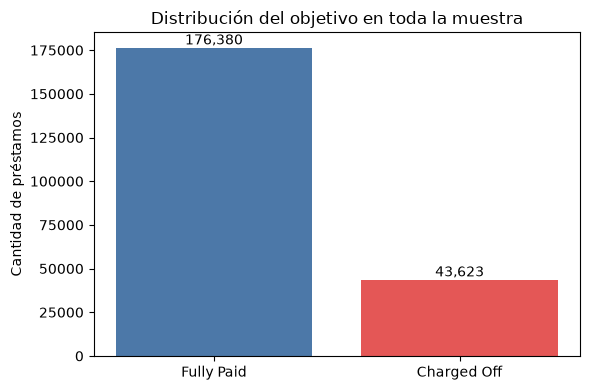

Lectura para el modelado:
La clase Charged Off es menos frecuente; por eso no usaremos solo accuracy.
La evaluación dará prioridad a detectar correctamente los incumplimientos.


In [10]:
conteo_objetivo = df["default"].value_counts().reindex([0, 1], fill_value=0)
etiquetas = ["Fully Paid", "Charged Off"]

fig = plt.figure(figsize=(6, 4))
plt.bar(etiquetas, conteo_objetivo.values, color=["#4C78A8", "#E45756"])
plt.title("Distribución del objetivo en toda la muestra")
plt.ylabel("Cantidad de préstamos")
for posicion, valor in enumerate(conteo_objetivo.values):
    plt.text(posicion, valor, f"{valor:,}", ha="center", va="bottom")
plt.tight_layout()
display(fig)
plt.close(fig)

print("Lectura para el modelado:")
print("La clase Charged Off es menos frecuente; por eso no usaremos solo accuracy.")
print("La evaluación dará prioridad a detectar correctamente los incumplimientos.")


## 7. Definir variables predictoras y reservar periodos

Primero separamos las variables que podrían entrar al modelo de las columnas auxiliares.
`loan_status` se utiliza para construir `default`, pero no entra como predictor.
La fecha de otorgamiento (`issue_d`) permite ordenar los préstamos y dividirlos por año.
Las variables de tasa, grado, cuota y financiación quedan fuera de las predictoras
hasta confirmar que estaban disponibles en el momento elegido para hacer la predicción.

### ¿Cómo dividimos los préstamos por año?

| Conjunto | Año de otorgamiento | ¿Para qué lo usamos? |
|---|---|---|
| Entrenamiento | Antes de 2015 (hasta 2014 inclusive) | Explorar las predictoras, decidir el tratamiento de faltantes y entrenar el modelo. |
| Validación | 2015 y 2016 | Comparar modelos y ajustes, y elegir el punto a partir del cual clasificamos un préstamo como posible incumplimiento. |
| Prueba | Desde 2017 | Evaluar el modelo elegido al final, cuando ya no vamos a cambiarlo según estos resultados. |

**El año corresponde a cuándo se otorgó el préstamo, no a cuándo terminó de pagarse.**
Las cantidades de filas de cada conjunto se muestran en la siguiente celda.

### ¿Por qué entrenamos con los años antiguos?

Queremos reproducir una situación real: aprender de préstamos del pasado y usar ese
conocimiento para predecir qué ocurrirá con préstamos posteriores. Por ejemplo,
entrenamos con préstamos otorgados hasta 2014, comparamos opciones con los de
2015–2016 y finalmente evaluamos con los de 2017 en adelante.

Si mezcláramos todos los años al azar, el entrenamiento podría incluir préstamos
más recientes que los usados para evaluar. Eso dificultaría comprobar si el modelo
funciona cuando cambian los perfiles de los clientes o las condiciones del crédito.
Usar los años antiguos no significa que sus datos sean mejores: permite respetar
el orden del tiempo y comprobar qué tan bien funciona el modelo en años posteriores.

### ¿Por qué los cortes son provisionales?

2015 y 2017 son una propuesta inicial para separar los periodos; todavía no hemos
demostrado que sean los mejores límites. Antes de entrenar debemos revisar las
cantidades por clase, los cambios en la información disponible y cuánto tiempo se
observó cada préstamo.

En particular, los préstamos duran 36 o 60 meses y solo conservamos los que tienen
un resultado final. Los préstamos recientes tuvieron menos tiempo para terminar:
al excluir los activos, podrían quedar principalmente los que se pagaron antes o
los que dejaron de pagar pronto. Por eso dividir por años no resuelve por sí solo
este problema. También debemos revisar la fecha hasta la que se actualizaron los
datos y si el resultado de cada préstamo ya habría sido conocido en la fecha en
que simulamos entrenar el modelo. Esa revisión puede llevarnos a cambiar los cortes
o a utilizar años con más tiempo de seguimiento.

`df` contiene toda la muestra. `df_eda` contiene solo entrenamiento;
`df_validacion` y `df_prueba` contienen los periodos reservados.


In [11]:
pendientes = ["funded_amnt", "funded_amnt_inv", "int_rate", "installment", "grade",
              "sub_grade", "initial_list_status", "disbursement_method"]
auxiliares = ["loan_status", "default", "issue_d", "fecha_prestamo", "anio"]
candidatas = [columna for columna in df.columns if columna not in pendientes + auxiliares]

print("Confirmar disponibilidad antes de usar en X:", pendientes)
print("Número de candidatas antes de revisar faltantes:", len(candidatas))

df_eda = df[df["anio"] < 2015].copy()
df_validacion = df[(df["anio"] >= 2015) & (df["anio"] < 2017)].copy()
df_prueba = df[df["anio"] >= 2017].copy()

print("Filas para EDA y entrenamiento:", len(df_eda))
print("Filas reservadas para validación:", len(df_validacion))
print("Filas reservadas para prueba:", len(df_prueba))

columnas_numericas = df_eda[candidatas].select_dtypes(include="number").columns.tolist()


Confirmar disponibilidad antes de usar en X: ['funded_amnt', 'funded_amnt_inv', 'int_rate', 'installment', 'grade', 'sub_grade', 'initial_list_status', 'disbursement_method']
Número de candidatas antes de revisar faltantes: 95
Filas para EDA y entrenamiento: 73701
Filas reservadas para validación: 109382
Filas reservadas para prueba: 36920


### 7.1. Excluir y recopilar variables según faltantes de entrenamiento

Aplicamos las siguientes reglas solo a las **candidatas predictoras**:

- **Más del 95%:** excluir de las matrices X, también si están totalmente vacías.
- **Más del 12% y menos del 95%:** conservar provisionalmente y recopilar para
  revisar su significado y decidir el tratamiento. Todavía no se imputan.
- **Exactamente 95%:** mostrar aparte para decidir; no se elimina con una regla
  estricta de "más del 95%". Exactamente 12% tampoco pertenece al intervalo de revisión.


In [12]:
UMBRAL_FALTANTES = 95
UMBRAL_REVISION = 12
faltantes_entrenamiento = df_eda[candidatas].isna().mean() * 100

resumen_faltantes_train = pd.DataFrame({
    "tipo": df_eda[candidatas].dtypes.astype(str),
    "datos_observados": df_eda[candidatas].notna().sum(),
    "datos_faltantes": df_eda[candidatas].isna().sum(),
    "porcentaje_faltante": faltantes_entrenamiento
}).sort_values("porcentaje_faltante", ascending=False)

tabla_excluidas_faltantes = resumen_faltantes_train[
    resumen_faltantes_train["porcentaje_faltante"] > UMBRAL_FALTANTES
].copy()
excluir_por_faltantes = tabla_excluidas_faltantes.index.tolist()
predictoras = [columna for columna in candidatas if columna not in excluir_por_faltantes]

tabla_revision_faltantes = resumen_faltantes_train[
    (resumen_faltantes_train["porcentaje_faltante"] > UMBRAL_REVISION) &
    (resumen_faltantes_train["porcentaje_faltante"] < UMBRAL_FALTANTES)
].copy()
tabla_revision_faltantes["tratamiento"] = "Pendiente de revisar significado y cobertura"
variables_a_revisar = tabla_revision_faltantes.index.tolist()

tabla_exactamente_95 = resumen_faltantes_train[
    resumen_faltantes_train["porcentaje_faltante"] == UMBRAL_FALTANTES
]

print("Variables excluidas por más del 95% de faltantes:", len(excluir_por_faltantes))
with pd.option_context("display.max_rows", None):
    display(tabla_excluidas_faltantes)
print("Variables para revisar (>12% y <95%):", len(variables_a_revisar))
with pd.option_context("display.max_rows", None):
    display(tabla_revision_faltantes)
if len(tabla_exactamente_95) > 0:
    print("Variables exactamente en 95%: pendientes de decisión")
    display(tabla_exactamente_95)
print("Predictoras conservadas provisionalmente:", len(predictoras))

X_entrenamiento = df_eda[predictoras].copy()
y_entrenamiento = df_eda["default"].copy()
X_validacion = df_validacion[predictoras].copy()
y_validacion = df_validacion["default"].copy()
X_prueba = df_prueba[predictoras].copy()
y_prueba = df_prueba["default"].copy()

columnas_numericas = X_entrenamiento.select_dtypes(include="number").columns.tolist()



Variables excluidas por más del 95% de faltantes: 30


,tipo,datos_observados,datos_faltantes,porcentaje_faltante
dti_joint,float64,0,73701,100.0
verification_status_joint,string,0,73701,100.0
open_acc_6m,float64,0,73701,100.0
annual_inc_joint,float64,0,73701,100.0
inq_fi,float64,0,73701,100.0
sec_app_open_act_il,float64,0,73701,100.0
sec_app_mths_since_last_major_derog,float64,0,73701,100.0
sec_app_fico_range_low,float64,0,73701,100.0
sec_app_fico_range_high,float64,0,73701,100.0
sec_app_earliest_cr_line,datetime64[us],0,73701,100.0


Variables para revisar (>12% y <95%): 31


,tipo,datos_observados,datos_faltantes,porcentaje_faltante,tratamiento
meses_desde_ultimo_registro_publico,float64,9781,63920,86.728810,Pendiente de revisar significado y cobertura
meses_desde_ultima_mora_tarjeta,float64,15856,57845,78.486045,Pendiente de revisar significado y cobertura
meses_desde_ultima_mora_grave,float64,15907,57794,78.416846,Pendiente de revisar significado y cobertura
meses_desde_ultima_mora_revolvente,float64,22191,51510,69.890504,Pendiente de revisar significado y cobertura
meses_desde_ultima_mora,float64,34201,39500,53.594931,Pendiente de revisar significado y cobertura
meses_desde_ultima_consulta_credito,float64,59294,14407,19.547903,Pendiente de revisar significado y cobertura
meses_desde_cuenta_plazos_mas_antigua,float64,60548,13153,17.846434,Pendiente de revisar significado y cobertura
cuentas_mora_120_dias_ultimos_2m,float64,61339,12362,16.773178,Pendiente de revisar significado y cobertura
pct_cuentas_sin_mora,float64,62598,11103,15.064924,Pendiente de revisar significado y cobertura
meses_desde_revolvente_mas_antigua,float64,62617,11084,15.039145,Pendiente de revisar significado y cobertura


Predictoras conservadas provisionalmente: 65


## 8. Correlación con el objetivo antes de rellenar faltantes

Mostramos únicamente la relación de cada predictora numérica conservada con
`loan_status`. Como el estado es texto, usamos su equivalente `default`:
**Fully Paid = 0 y Charged Off = 1**. El objetivo no se incluye entre las predictoras.

Para facilitar la lectura, dividimos las predictoras ordenadas alfabéticamente en
cuatro grupos (A, B, C y D). Cada mapa tiene una sola columna: la correlación de
Spearman con el objetivo. Usamos solo los préstamos de entrenamiento.

- Un valor positivo indica que los valores altos de la predictora tienden a asociarse con Charged Off.
- Un valor negativo indica que tienden a asociarse con Fully Paid.
- Cerca de cero indica una relación débil según esta medida; no demuestra que la variable sea inútil.

Antes de rellenar, cada cálculo usa las filas donde están presentes la predictora
y el objetivo. La tabla muestra cuántos pares válidos se utilizaron. Las variables
constantes o sin suficientes datos aparecen en gris; eso no significa correlación cero.
Las categorías y fechas quedan fuera de este cálculo numérico. Una correlación
no demuestra causa ni determina por sí sola qué variables debemos eliminar.


Variables no numéricas, fuera de esta correlación:
['antiguedad_laboral', 'tenencia_vivienda', 'verificacion_ingresos', 'proposito_prestamo', 'estado_residencia', 'fecha_primera_linea_credito', 'tipo_solicitud']


,correlacion_target,pares_validos
cobranzas_no_medicas_12m,0.006473,73688
consultas_credito_6m,0.058795,73701
credito_disponible_tarjetas,-0.084634,65290
cuentas_abiertas_12m,0.079715,62618
cuentas_abiertas_ultimos_24m,0.087720,65922
cuentas_castigadas_12m,0.001617,73688
cuentas_con_mora_120_dias,0.015013,62618
cuentas_en_mora_actual,0.008583,73701
cuentas_hipotecarias,-0.058355,65922
cuentas_mora_120_dias_ultimos_2m,0.002195,61339


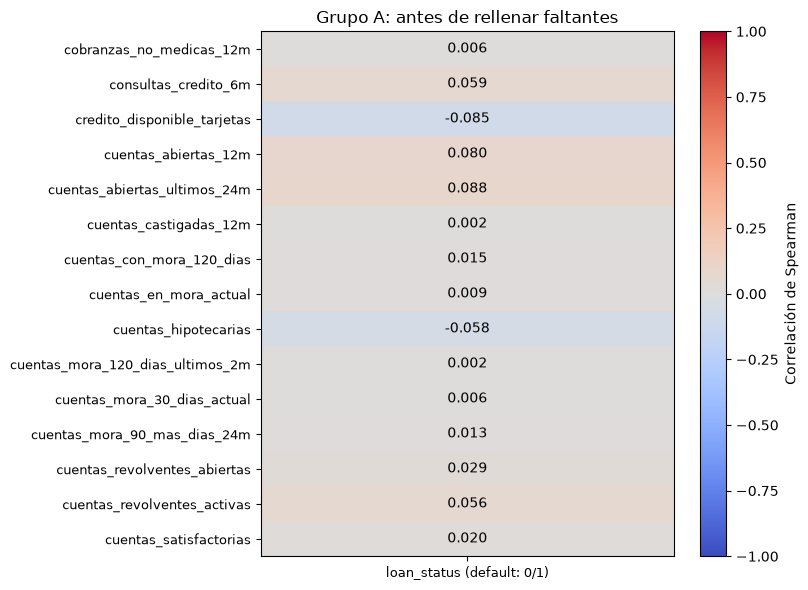

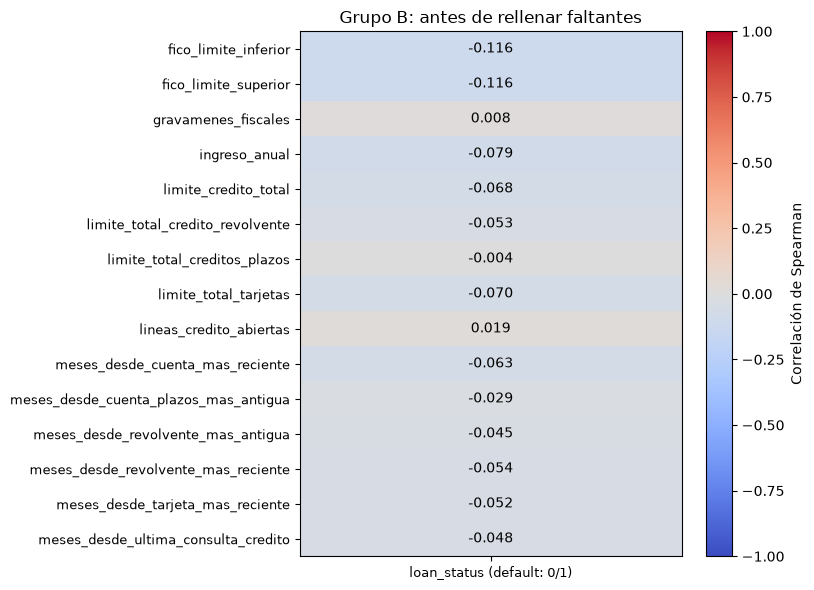

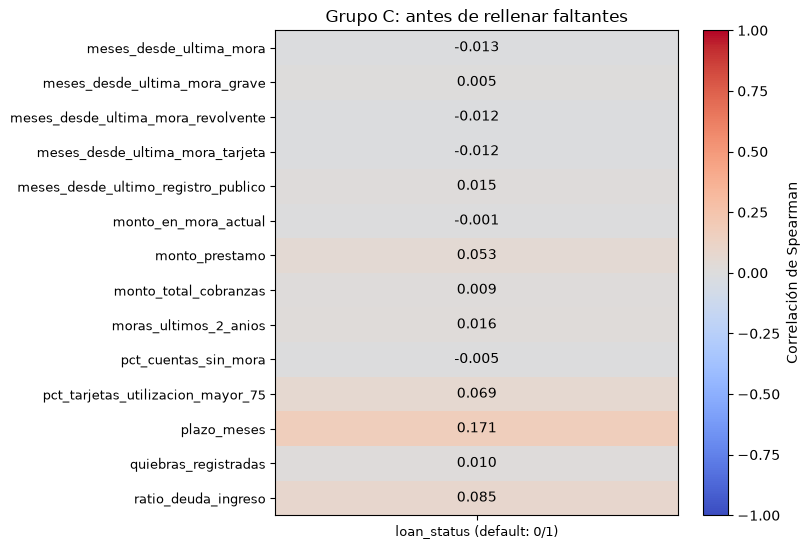

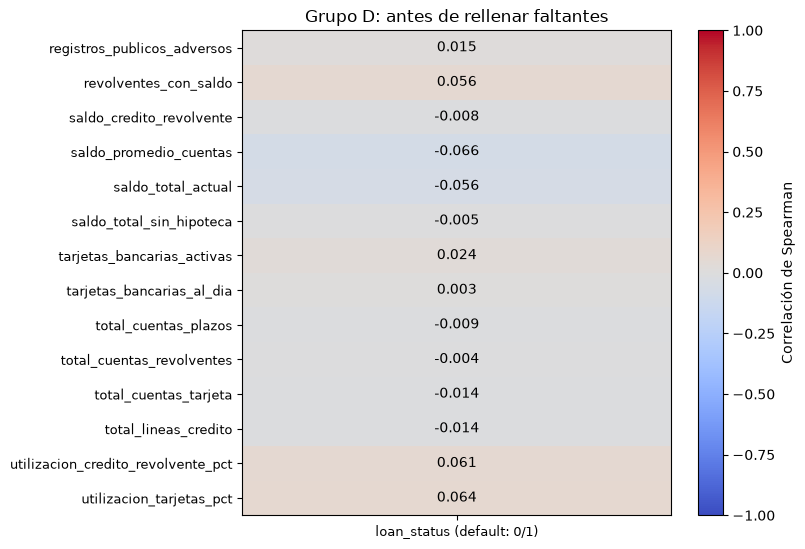

In [13]:
# loan_status es texto; usamos default: Fully Paid = 0, Charged Off = 1.
variables_correlacion = sorted(X_entrenamiento.select_dtypes(include="number").columns.tolist())
grupos_correlacion = {}
for nombre, columnas in zip(["A", "B", "C", "D"], np.array_split(variables_correlacion, 4)):
    grupos_correlacion[nombre] = columnas.tolist()

print("Variables no numéricas, fuera de esta correlación:")
print(X_entrenamiento.select_dtypes(exclude="number").columns.tolist())

def mostrar_correlacion_objetivo(tabla, momento):
    colores = plt.get_cmap("coolwarm").copy()
    colores.set_bad("lightgray")
    for grupo, variables in grupos_correlacion.items():
        bloque = tabla.loc[variables, ["correlacion_target"]]
        fig, eje = plt.subplots(figsize=(8, max(5, len(variables) * 0.4)))
        imagen = eje.imshow(bloque, cmap=colores, vmin=-1, vmax=1, aspect="auto")
        fig.colorbar(imagen, ax=eje, label="Correlación de Spearman")
        eje.set_xticks([0], labels=["loan_status (default: 0/1)"])
        eje.set_yticks(range(len(variables)), labels=variables)
        eje.tick_params(labelsize=9)
        eje.set_title(f"Grupo {grupo}: {momento}")
        for fila, valor in enumerate(bloque["correlacion_target"]):
            etiqueta = f"{valor:.3f}" if pd.notna(valor) else "Sin correlación calculable"
            color_texto = "white" if pd.notna(valor) and abs(valor) > 0.65 else "black"
            eje.text(0, fila, etiqueta, ha="center", va="center", color=color_texto)
        fig.tight_layout()
        display(fig)
        plt.close(fig)

# Cada cálculo utiliza solo las filas donde existen la predictora y el objetivo.
correlacion_target_antes = X_entrenamiento[variables_correlacion].corrwith(
    y_entrenamiento, method="spearman"
).to_frame("correlacion_target")
correlacion_target_antes["pares_validos"] = (
    X_entrenamiento[variables_correlacion].notna()
    .mul(y_entrenamiento.notna(), axis=0).sum()
)
with pd.option_context("display.max_rows", None):
    display(correlacion_target_antes)
mostrar_correlacion_objetivo(correlacion_target_antes, "antes de rellenar faltantes")


## 9. Guardar la muestra (opcional)

La muestra existe en memoria como `df`. Para crear un archivo independiente, quitar
el símbolo `#` de las siguientes tres líneas y ejecutar la celda. El archivo guardado
será una **muestra de exploración**, sin las columnas descartadas antes del muestreo.
Todavía contiene el objetivo, fechas y variables pendientes de revisión. Para
modelar utilizaremos las matrices X e y definidas en la sección 8.1. Esta celda no guarda nada
mientras esté comentada. El dataset original no se modifica.


In [14]:
# carpeta_muestra = carpeta / "data" / "processed"
# carpeta_muestra.mkdir(parents=True, exist_ok=True)
# df.to_csv(carpeta_muestra / "muestra_eda.csv", index=False)


## 10. Diagnóstico de las 31 variables pendientes

Antes de proponer una imputación, revisamos **solo entrenamiento**:
1. Porcentaje de faltantes por año.
2. Si varias columnas faltan exactamente en las mismas filas.
3. Distribución observada, incluyendo ceros, mediana y valores distintos.
4. Relación de los faltantes con otros antecedentes conocidos.

Un patrón temporal sugiere cambios de cobertura, pero por sí solo no demuestra
cuándo comenzó a recopilarse una variable. Tampoco un faltante demuestra ausencia
de mora o de una cuenta. No se aplica ninguna imputación en estas celdas.


In [15]:
faltantes_por_anio = df_eda.groupby("anio")[variables_a_revisar].agg(lambda columna: columna.isna().mean() * 100).T
print("Porcentaje faltante por año de otorgamiento (entrenamiento):")
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(faltantes_por_anio.round(2))

patron_base = df_eda["saldo_total_actual"].isna()
diagnostico = []
for columna in variables_a_revisar:
    datos = df_eda[columna]
    faltantes = datos.isna()
    observados = datos.dropna()
    diagnostico.append({
        "variable": columna,
        "porcentaje_faltante": faltantes.mean() * 100,
        "mediana_observada": observados.median(),
        "porcentaje_ceros_observados": observados.eq(0).mean() * 100,
        "valores_distintos": observados.nunique(),
        "mismo_patron_que_tot_cur_bal": faltantes.equals(patron_base),
        "faltantes_adicionales_al_patron": int((faltantes & ~patron_base).sum()),
        "datos_presentes_donde_falta_patron": int((~faltantes & patron_base).sum())
    })
diagnostico_faltantes = pd.DataFrame(diagnostico).set_index("variable")
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(diagnostico_faltantes.round(3))


Porcentaje faltante por año de otorgamiento (entrenamiento):


anio,2007,2008,2009,2010,2011,2012,2013,2014
meses_desde_ultimo_registro_publico,6.25,58.8,96.18,94.49,94.79,97.19,88.17,82.26
meses_desde_ultima_mora_tarjeta,100.00,100.0,100.00,100.00,100.00,87.20,77.63,73.07
meses_desde_ultima_mora_grave,100.00,100.0,100.00,100.00,100.00,89.54,79.43,71.28
meses_desde_ultima_mora_revolvente,100.00,100.0,100.00,100.00,100.00,73.63,69.93,63.59
meses_desde_ultima_mora,6.25,40.0,67.73,65.38,66.50,58.95,56.27,48.68
meses_desde_ultima_consulta_credito,100.00,100.0,100.00,100.00,100.00,25.19,10.94,9.02
meses_desde_cuenta_plazos_mas_antigua,100.00,100.0,100.00,100.00,100.00,54.75,3.64,2.92
cuentas_mora_120_dias_ultimos_2m,100.00,100.0,100.00,100.00,100.00,52.39,0.16,3.41
pct_cuentas_sin_mora,100.00,100.0,100.00,100.00,100.00,52.39,0.09,0.00
meses_desde_revolvente_mas_antigua,100.00,100.0,100.00,100.00,100.00,52.40,0.00,0.00


,porcentaje_faltante,mediana_observada,porcentaje_ceros_observados,valores_distintos,mismo_patron_que_tot_cur_bal,faltantes_adicionales_al_patron,datos_presentes_donde_falta_patron
variable,,,,,,,
meses_desde_ultimo_registro_publico,86.729,78.0,1.196,121,False,53443,606
meses_desde_ultima_mora_tarjeta,78.486,40.0,0.170,112,False,46762,0
meses_desde_ultima_mora_grave,78.417,42.0,0.057,119,False,46711,0
meses_desde_ultima_mora_revolvente,69.891,34.0,0.216,116,False,41251,824
meses_desde_ultima_mora,53.595,31.0,0.412,112,False,32228,3811
meses_desde_ultima_consulta_credito,19.548,6.0,8.930,26,False,6165,2841
meses_desde_cuenta_plazos_mas_antigua,17.846,129.0,0.005,399,False,2070,0
cuentas_mora_120_dias_ultimos_2m,16.773,0.0,99.936,2,False,1279,0
pct_cuentas_sin_mora,15.065,100.0,0.000,366,False,20,0


In [16]:
comparaciones = [
    ("meses_desde_ultimo_registro_publico", "registros_publicos_adversos"),
    ("meses_desde_ultima_mora", "moras_ultimos_2_anios"),
    ("meses_desde_ultima_mora_grave", "cuentas_con_mora_120_dias"),
    ("meses_desde_ultima_consulta_credito", "consultas_credito_6m"),
    ("meses_desde_cuenta_plazos_mas_antigua", "total_cuentas_plazos"),
    ("meses_desde_ultima_mora_tarjeta", "total_cuentas_tarjeta"),
    ("meses_desde_ultima_mora_revolvente", "total_cuentas_revolventes")
]
cruces = []
for variable, referencia in comparaciones:
    for nombre, grupo in [("referencia_cero", df_eda[referencia].eq(0)),
                          ("referencia_positiva", df_eda[referencia].gt(0))]:
        valores = df_eda.loc[grupo, variable]
        cruces.append({"variable": variable, "referencia": referencia,
                       "grupo": nombre, "filas": len(valores),
                       "cantidad_faltantes": valores.isna().sum(),
                       "porcentaje_faltante": valores.isna().mean() * 100})
cruces_faltantes = pd.DataFrame(cruces)
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(cruces_faltantes.round(2))
print("Grupos con referencia nula no se incluyen en estas comparaciones.")


,variable,referencia,grupo,filas,cantidad_faltantes,porcentaje_faltante
0,meses_desde_ultimo_registro_publico,registros_publicos_adversos,referencia_cero,64036,63920,99.82
1,meses_desde_ultimo_registro_publico,registros_publicos_adversos,referencia_positiva,9665,0,0.00
2,meses_desde_ultima_mora,moras_ultimos_2_anios,referencia_cero,60606,39420,65.04
3,meses_desde_ultima_mora,moras_ultimos_2_anios,referencia_positiva,13095,80,0.61
4,meses_desde_ultima_mora_grave,cuentas_con_mora_120_dias,referencia_cero,49018,46244,94.34
5,meses_desde_ultima_mora_grave,cuentas_con_mora_120_dias,referencia_positiva,13600,467,3.43
6,meses_desde_ultima_consulta_credito,consultas_credito_6m,referencia_cero,38349,10431,27.20
7,meses_desde_ultima_consulta_credito,consultas_credito_6m,referencia_positiva,35352,3976,11.25
8,meses_desde_cuenta_plazos_mas_antigua,total_cuentas_plazos,referencia_cero,2076,2068,99.61
9,meses_desde_cuenta_plazos_mas_antigua,total_cuentas_plazos,referencia_positiva,60542,2,0.00


Grupos con referencia nula no se incluyen en estas comparaciones.


## 11. Aplicar mediana e indicador de faltante

**Tratamiento aplicado en las celdas siguientes: conservar las 31 variables e imputar cada
una con la mediana de entrenamiento más un indicador de faltante** (1 si el dato
original faltaba, 0 si estaba observado). No hay evidencia suficiente para excluir
otra columna solo por su porcentaje de nulos.

### Justificación de los indicadores de faltantes

La documentación de scikit-learn explica que conservar la información sobre qué
datos estaban ausentes puede aportar información al modelo, y describe
`MissingIndicator` y la opción `add_indicator` para hacerlo (scikit-learn developers,
s. f., apartado “Marking imputed values”).

Por eso combinamos dos pasos: **rellenar con la mediana** trata el dato faltante;
**añadir el indicador 0/1**. El indicador permite
que el modelo distinga un valor observado de uno rellenado, aunque ambos tengan
el mismo número. No recupera el valor real que desconocemos.

En este proyecto añadimos un indicador a cada una de las 31 variables revisadas
como propuesta inicial. La referencia respalda la técnica, **no el umbral del 12%
ni que los 31 indicadores mejoren nuestro modelo**: esas son decisiones del proyecto.
Los faltantes también pueden reflejar cambios en el registro de datos entre años.
Para decidir si conservar los indicadores, compararemos el mismo modelo con
mediana sola y con mediana más indicadores, usando los mismos periodos y métricas
de validación. Esta comparación aún está pendiente (scikit-learn developers, s. f.). 


### Tratamiento por variable

Para cada variable: **mediana de entrenamiento + indicador de faltante**. La tabla conserva el motivo del tratamiento; las medianas y cantidades actualizadas se calculan y muestran en 12.1.

| Variable | Tratamiento | Justificación o precaución |
|---|---|---|
| `meses_desde_ultimo_registro_publico` | Mediana + indicador | Ausencia compatible con no tener registros: revisar la relación con registros_publicos_adversos en el diagnóstico. |
| `meses_desde_ultima_mora_tarjeta` | Mediana + indicador | No asumir que el faltante significa que nunca hubo mora; también hay cobertura temporal incompleta. |
| `meses_desde_ultima_mora_grave` | Mediana + indicador | El antecedente de 90 días no es equivalente al conteo de cuentas con 120 días; conservar el indicador de ausencia. |
| `meses_desde_ultima_mora_revolvente` | Mediana + indicador | No sustituir por cero meses ni asumir ausencia de mora. |
| `meses_desde_ultima_mora` | Mediana + indicador | Puede haber faltantes aun con moras_ultimos_2_anios positivo: no significa siempre que nunca hubo mora. |
| `meses_desde_ultima_consulta_credito` | Mediana + indicador | Hay faltantes aun cuando consultas_credito_6m es positivo; no asumir que no hubo consultas. |
| `meses_desde_cuenta_plazos_mas_antigua` | Mediana + indicador | El faltante adicional se concentra en total_cuentas_plazos = 0; conservar ese conteo para dar contexto. |
| `cuentas_mora_120_dias_ultimos_2m` | Mediana + indicador | Revisar la proporción de ceros en el diagnóstico. Conservar inicialmente y revisar su utilidad, no borrar automáticamente. |
| `pct_cuentas_sin_mora` | Mediana + indicador | Una mediana de 100, si se obtiene, no es garantía de que una historia desconocida nunca haya tenido mora. |
| `meses_desde_revolvente_mas_reciente` | Mediana + indicador | Cobertura temporal común y una ausencia adicional. |
| `meses_desde_revolvente_mas_antigua` | Mediana + indicador | Cobertura temporal común y una ausencia adicional. |
| `meses_desde_cuenta_mas_reciente` | Mediana + indicador | Patrón temporal común. |
| `total_cuentas_plazos` | Mediana + indicador | Conteo; conservar ceros originales. |
| `revolventes_con_saldo` | Mediana + indicador | Conteo; patrón temporal común. |
| `total_cuentas_tarjeta` | Mediana + indicador | Conteo; patrón temporal común. |
| `cuentas_mora_30_dias_actual` | Mediana + indicador | Revisar la proporción de ceros en el diagnóstico. El indicador distingue desconocido de cero observado. |
| `total_cuentas_revolventes` | Mediana + indicador | Conteo; patrón temporal común. |
| `cuentas_revolventes_activas` | Mediana + indicador | Conteo; patrón temporal común. |
| `limite_total_creditos_plazos` | Mediana + indicador | Límite monetario; conservar ceros reales e imputar la mediana solo en faltantes. |
| `limite_credito_total` | Mediana + indicador | Límite monetario; mediana para reducir influencia de extremos. |
| `saldo_promedio_cuentas` | Mediana + indicador | Saldo promedio; no reconstruir con fórmulas sin confirmar la equivalencia en el diccionario. |
| `tarjetas_bancarias_activas` | Mediana + indicador | Conteo; patrón temporal común. |
| `limite_total_credito_revolvente` | Mediana + indicador | Límite monetario; patrón temporal común. |
| `cuentas_mora_90_mas_dias_24m` | Mediana + indicador | No afirmar ausencia de mora en un valor imputado: acompañarlo con indicador. |
| `cuentas_abiertas_12m` | Mediana + indicador | Conteo; patrón temporal común. |
| `saldo_total_actual` | Mediana + indicador | Saldo total; la mediana evita asumir saldo cero. |
| `monto_total_cobranzas` | Mediana + indicador | Revisar la proporción de ceros en el diagnóstico. Imputar cero por ser mediana, no porque se conozca ausencia de cobranzas. |
| `cuentas_con_mora_120_dias` | Mediana + indicador | Conteo de antecedentes; mantener indicador para diferenciar desconocido de ausencia observada. |
| `cuentas_revolventes_abiertas` | Mediana + indicador | Conteo; patrón temporal común. |
| `cuentas_satisfactorias` | Mediana + indicador | Completa en 2013–2014; faltantes concentrados en años anteriores. |
| `tarjetas_bancarias_al_dia` | Mediana + indicador | Completa en 2013–2014; faltantes concentrados en años anteriores. |



Las siguientes celdas crean `X_entrenamiento_imputado`, `X_validacion_imputado`
y `X_prueba_imputado`. 

### 11.1. Calcular medianas y aplicar el tratamiento a las variables con más de 12% y menos de 95% de datos faltantes

In [17]:
columnas_imputar = variables_a_revisar.copy()

medianas_entrenamiento = X_entrenamiento[columnas_imputar].median()
assert medianas_entrenamiento.notna().all(), "Hay una columna sin mediana disponible."

X_entrenamiento_imputado = X_entrenamiento.copy()
X_validacion_imputado = X_validacion.copy()
X_prueba_imputado = X_prueba.copy()

for columna in columnas_imputar:
    mediana = medianas_entrenamiento[columna]
    for tabla in [X_entrenamiento_imputado, X_validacion_imputado, X_prueba_imputado]:

        tabla[columna + "_faltante"] = tabla[columna].isna().astype("int8")
        tabla[columna] = tabla[columna].fillna(mediana)

resumen_imputacion = pd.DataFrame({
    "mediana_entrenamiento": medianas_entrenamiento,
    "rellenados_entrenamiento": X_entrenamiento[columnas_imputar].isna().sum(),
    "rellenados_validacion": X_validacion[columnas_imputar].isna().sum(),
    "rellenados_prueba": X_prueba[columnas_imputar].isna().sum()
})
resumen_imputacion["indicador_creado"] = resumen_imputacion.index + "_faltante"
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(resumen_imputacion)
print("Variables tratadas:", len(columnas_imputar))
print("Columnas después de añadir indicadores:", X_entrenamiento_imputado.shape[1])


,mediana_entrenamiento,rellenados_entrenamiento,rellenados_validacion,rellenados_prueba,indicador_creado
meses_desde_ultimo_registro_publico,78.0,63920,88684,30025,meses_desde_ultimo_registro_publico_faltante
meses_desde_ultima_mora_tarjeta,40.0,57845,81310,28545,meses_desde_ultima_mora_tarjeta_faltante
meses_desde_ultima_mora_grave,42.0,57794,77177,27027,meses_desde_ultima_mora_grave_faltante
meses_desde_ultima_mora_revolvente,34.0,51510,70068,24803,meses_desde_ultima_mora_revolvente_faltante
meses_desde_ultima_mora,31.0,39500,52648,18874,meses_desde_ultima_mora_faltante
meses_desde_ultima_consulta_credito,6.0,14407,10785,3280,meses_desde_ultima_consulta_credito_faltante
meses_desde_cuenta_plazos_mas_antigua,129.0,13153,3105,1045,meses_desde_cuenta_plazos_mas_antigua_faltante
cuentas_mora_120_dias_ultimos_2m,0.0,12362,5152,1645,cuentas_mora_120_dias_ultimos_2m_faltante
pct_cuentas_sin_mora,100.0,11103,0,0,pct_cuentas_sin_mora_faltante
meses_desde_revolvente_mas_antigua,164.0,11084,0,0,meses_desde_revolvente_mas_antigua_faltante


Variables tratadas: 31
Columnas después de añadir indicadores: 96


### 11.2. Completar los faltantes de las variables restantes

Las variables numéricas restantes se rellenan con su **mediana de entrenamiento**.
`antiguedad_laboral` se rellena con la categoría `Sin información`.
Aunque una variable numérica solo tenga faltantes en validación o prueba, usamos la mediana
de entrenamiento; nunca calculamos otra con esos conjuntos.

Calculamos medianas para todas las numéricas restantes, aunque alguna no tenga
nulos en entrenamiento. Esto permite tratar faltantes nuevos sin cambiar la regla.
Conservamos los 31 indicadores creados anteriormente. No añadimos indicadores
adicionales en este paso. Los objetivos y las matrices originales permanecen intactos.

Para que la celda pueda ejecutarse de nuevo, reconstruimos las matrices a partir
de las originales y reaplicamos las medianas e indicadores ya aprendidos en 11.1.

Aquí se incluyen las numéricas con 12% o menos de faltantes y las que solo tienen faltantes en validación o prueba. La tabla final resume las variables adicionales tratadas.


In [18]:
# Contar los faltantes adicionales desde las matrices originales.
# Así esta celda no depende de la sección eliminada y puede volver a ejecutarse.
pendientes_imputacion = pd.DataFrame({
    "entrenamiento": X_entrenamiento.isna().sum(),
    "validacion": X_validacion.isna().sum(),
    "prueba": X_prueba.isna().sum()
})
pendientes_imputacion = pendientes_imputacion.loc[
    ~pendientes_imputacion.index.isin(columnas_imputar)
]
pendientes_imputacion = pendientes_imputacion[
    pendientes_imputacion.sum(axis=1) > 0
]

categoricas_rellenar = ["antiguedad_laboral"]
numericas_restantes = X_entrenamiento.select_dtypes(include="number").columns.tolist()
numericas_restantes = [columna for columna in numericas_restantes if columna not in columnas_imputar]
medianas_restantes = X_entrenamiento[numericas_restantes].median()
assert medianas_restantes.notna().all(), "Revisar columnas sin mediana de entrenamiento."

X_entrenamiento_imputado = X_entrenamiento.copy()
X_validacion_imputado = X_validacion.copy()
X_prueba_imputado = X_prueba.copy()

for tabla in [X_entrenamiento_imputado, X_validacion_imputado, X_prueba_imputado]:
   
    for columna in columnas_imputar:
        tabla[columna + "_faltante"] = tabla[columna].isna().astype("int8")
        tabla[columna] = tabla[columna].fillna(medianas_entrenamiento[columna])

    tabla[numericas_restantes] = tabla[numericas_restantes].fillna(medianas_restantes)

    for columna in categoricas_rellenar:
        tabla[columna] = tabla[columna].fillna("Sin información")

variables_adicionales = pendientes_imputacion.index.tolist()
tratamientos_adicionales = []
for columna in variables_adicionales:
    if columna in categoricas_rellenar:
        metodo = "Categoría explícita"
        valor = "Sin información"
    else:
        metodo = "Mediana de entrenamiento"
        valor = medianas_restantes[columna]
    tratamientos_adicionales.append({"variable": columna, "tratamiento": metodo, "valor_utilizado": valor})

tabla_tratamientos_adicionales = pd.DataFrame(tratamientos_adicionales, columns=["variable", "tratamiento", "valor_utilizado"]).set_index("variable")
tabla_tratamientos_adicionales = tabla_tratamientos_adicionales.join(pendientes_imputacion)
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(tabla_tratamientos_adicionales)


,tratamiento,valor_utilizado,entrenamiento,validacion,prueba
variable,,,,,
antiguedad_laboral,Categoría explícita,Sin información,3376,6753,2818
ratio_deuda_ingreso,Mediana de entrenamiento,16.81,0,13,49
consultas_credito_6m,Mediana de entrenamiento,0.0,0,1,0
utilizacion_credito_revolvente_pct,Mediana de entrenamiento,57.3,56,49,35
cobranzas_no_medicas_12m,Mediana de entrenamiento,0.0,13,0,0
cuentas_abiertas_ultimos_24m,Mediana de entrenamiento,4.0,7779,0,0
credito_disponible_tarjetas,Mediana de entrenamiento,3554.5,8411,1112,523
utilizacion_tarjetas_pct,Mediana de entrenamiento,70.2,8451,1164,554
cuentas_castigadas_12m,Mediana de entrenamiento,0.0,13,0,0


### 11.3. Verificación final de faltantes

Comprobamos que no queden nulos en ninguna de las tres matrices imputadas, que las
medianas procedan de entrenamiento y que los valores observados se conserven.
Tener cero nulos no implica que el baseline ya esté preparado: todavía falta
codificar categorías, transformar fechas en características y escalar las numéricas.


In [19]:
medianas_todas = pd.concat([medianas_entrenamiento, medianas_restantes])
for original, tratado in [(X_entrenamiento, X_entrenamiento_imputado),
                          (X_validacion, X_validacion_imputado),
                          (X_prueba, X_prueba_imputado)]:
    assert original.index.equals(tratado.index)
    assert tratado.notna().all().all(), "Todavía hay faltantes sin tratar."
    for columna in original.columns:
        faltaba = original[columna].isna()
        assert tratado.loc[~faltaba, columna].equals(original.loc[~faltaba, columna])
        if columna in categoricas_rellenar:
            assert tratado.loc[faltaba, columna].eq("Sin información").all()
        elif columna in medianas_todas.index:
            assert tratado.loc[faltaba, columna].eq(medianas_todas[columna]).all()
        if columna in columnas_imputar:
            assert tratado[columna + "_faltante"].eq(faltaba.astype("int8")).all()

assert list(X_entrenamiento_imputado.columns) == list(X_validacion_imputado.columns) == list(X_prueba_imputado.columns)
assert X_entrenamiento_imputado.index.equals(y_entrenamiento.index)
assert X_validacion_imputado.index.equals(y_validacion.index)
assert X_prueba_imputado.index.equals(y_prueba.index)

verificacion_final = pd.DataFrame({
    "conjunto": ["Entrenamiento", "Validación", "Prueba"],
    "filas": [len(X_entrenamiento_imputado), len(X_validacion_imputado), len(X_prueba_imputado)],
    "columnas": [X_entrenamiento_imputado.shape[1], X_validacion_imputado.shape[1], X_prueba_imputado.shape[1]],
    "nulos_restantes": [X_entrenamiento_imputado.isna().sum().sum(),
                       X_validacion_imputado.isna().sum().sum(),
                       X_prueba_imputado.isna().sum().sum()]
})
display(verificacion_final)
print("Imputación completa. Valores originales e indicadores comprobados.")
print("Siguiente preparación: codificar categorías, transformar fechas y escalar para el baseline.")

assert "zip_code" not in df.columns
assert "zip_code" not in X_entrenamiento_imputado.columns
assert len(df_eda) + len(df_validacion) + len(df_prueba) == len(df)
assert set(df_eda.index).isdisjoint(df_validacion.index)
assert set(df_eda.index).isdisjoint(df_prueba.index)
assert set(df_validacion.index).isdisjoint(df_prueba.index)


,conjunto,filas,columnas,nulos_restantes
0,Entrenamiento,73701,96,0
1,Validación,109382,96,0
2,Prueba,36920,96,0


Imputación completa. Valores originales e indicadores comprobados.
Siguiente preparación: codificar categorías, transformar fechas y escalar para el baseline.


## 12. Identificar posibles outliers con IQR (después de tratar faltantes)

Q1 y Q3 delimitan el 50% central de los datos. La distancia entre ambos es el IQR.
Marcamos valores menores que `Q1 - 1.5 × IQR` o mayores que `Q3 + 1.5 × IQR`.

Después de aplicar las reglas de faltantes, repetimos el cálculo para cada columna numérica candidata usando un `for`.
No aplicamos la regla a columnas binarias, constantes o con IQR cero, porque puede
dar alertas poco útiles en esos casos. Las reportamos aparte.
**Un outlier no es necesariamente un error. No eliminaremos filas automáticamente.**

El porcentaje usa los valores finitos después de rellenar faltantes. La mediana puede cambiar los límites IQR; estas alertas describen la tabla tratada y no prueban errores.


In [20]:
resultados = []
sin_criterio_iqr = []

for columna in columnas_numericas:
    valores = X_entrenamiento_imputado[columna].dropna()
    valores = valores[np.isfinite(valores)]
    q1 = valores.quantile(0.25)
    q3 = valores.quantile(0.75)
    iqr = q3 - q1

    if valores.nunique() <= 2 or iqr == 0 or valores.empty:
        sin_criterio_iqr.append(columna)
        continue

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    alertas = (valores < limite_inferior) | (valores > limite_superior)
    resultados.append({"variable": columna, "datos_evaluados": len(valores),
                       "cantidad_outliers": int(alertas.sum()),
                       "porcentaje_outliers": alertas.mean() * 100,
                       "limite_inferior": limite_inferior,
                       "limite_superior": limite_superior})

tabla_outliers = pd.DataFrame(resultados).sort_values("porcentaje_outliers", ascending=False)
display(tabla_outliers.head(20))
print("Variables que requieren otro criterio:", sin_criterio_iqr)


,variable,datos_evaluados,cantidad_outliers,porcentaje_outliers,limite_inferior,limite_superior
16,meses_desde_cuenta_plazos_mas_antigua,73701,8294,11.253579,49.50,205.50
21,meses_desde_tarjeta_mas_reciente,73701,7899,10.717629,-23.00,57.00
14,credito_disponible_tarjetas,73701,7853,10.655215,-9362.50,19137.50
18,meses_desde_revolvente_mas_reciente,73701,6464,8.770573,-11.00,29.00
33,pct_cuentas_sin_mora,73701,5741,7.789582,83.25,110.05
5,consultas_credito_6m,73701,5541,7.518215,-1.50,2.50
19,meses_desde_cuenta_mas_reciente,73701,5403,7.330972,-6.00,18.00
11,limite_total_credito_revolvente,73701,5294,7.183078,-13750.00,62650.00
37,limite_total_tarjetas,73701,5149,6.986337,-16150.00,48250.00
36,saldo_total_sin_hipoteca,73701,4894,6.640344,-26893.50,102174.50


Variables que requieren otro criterio: ['plazo_meses', 'moras_ultimos_2_anios', 'meses_desde_ultima_mora', 'meses_desde_ultimo_registro_publico', 'registros_publicos_adversos', 'cobranzas_no_medicas_12m', 'meses_desde_ultima_mora_grave', 'cuentas_en_mora_actual', 'monto_total_cobranzas', 'cuentas_castigadas_12m', 'monto_en_mora_actual', 'meses_desde_ultima_mora_tarjeta', 'meses_desde_ultima_mora_revolvente', 'cuentas_con_mora_120_dias', 'cuentas_mora_120_dias_ultimos_2m', 'cuentas_mora_30_dias_actual', 'cuentas_mora_90_mas_dias_24m', 'quiebras_registradas', 'gravamenes_fiscales']


## 13. Revisar datos sospechosos después de los outliers

Revisamos los préstamos elegibles (`Fully Paid` y `Charged Off`) del archivo completo, mediante lectura por bloques. Esta revisión usa reglas
fijas de coherencia y se realiza después de identificar los valores extremos.

Buscamos montos no positivos, ingresos negativos o cero, saldos negativos,
valores FICO fuera de 300–850 o límites invertidos, plazos distintos de 36/60
meses y fechas del historial posteriores al otorgamiento. También contamos valores
infinitos en las variables numéricas revisadas y formatos de fecha o plazo no reconocidos.

Son **alertas para revisar**, no una orden de borrar filas. Un ingreso cero o un
DTI negativo requieren comprobar su significado. Los faltantes se estudian aparte;
no se consideran errores por sí solos. Una utilización de crédito mayor al 100%
tampoco se clasifica automáticamente como error.

Mostramos los conteos y hasta diez ejemplos. Una fila puede activar varias reglas.
Esta sección no modifica el archivo ni elimina préstamos. Los resultados se usan para decidir si algún valor debe convertirse en faltante en una etapa posterior. Los errores confirmados
necesitarán una regla de tratamiento justificada antes de entrenar.


In [21]:
columnas_revision = ["loan_status", "loan_amnt", "annual_inc", "dti",
                     "revol_bal", "fico_range_low", "fico_range_high",
                     "term", "earliest_cr_line", "issue_d"]
resumen_alertas = pd.Series(dtype="int64")
ejemplos_alertas = []
filas_revisadas = 0
filas_con_alerta = 0

lector_revision = pd.read_csv(
    archivo, usecols=columnas_revision,
    dtype={columna: tipos_lectura[columna] for columna in columnas_revision},
    chunksize=TAMANO_BLOQUE, skipinitialspace=True
)
for bloque_revision in lector_revision:
    datos_revision = bloque_revision[
        bloque_revision["loan_status"].isin(estados_conservados)
    ].copy()
    fechas_credito = pd.to_datetime(datos_revision["earliest_cr_line"], format="%b-%Y", errors="coerce")
    fechas_prestamo = pd.to_datetime(datos_revision["issue_d"], format="%b-%Y", errors="coerce")
    plazos = pd.to_numeric(
        datos_revision["term"].str.strip().str.replace(" months", "", regex=False), errors="coerce"
    )
    numericas_revision = datos_revision.select_dtypes(include="number")
    reglas = pd.DataFrame({
        "ingreso_negativo": datos_revision["annual_inc"] < 0,
        "ingreso_cero": datos_revision["annual_inc"] == 0,
        "monto_no_positivo": datos_revision["loan_amnt"] <= 0,
        "dti_negativo": datos_revision["dti"] < 0,
        "saldo_revolvente_negativo": datos_revision["revol_bal"] < 0,
        "fico_invertido": datos_revision["fico_range_low"] > datos_revision["fico_range_high"],
        "fico_fuera_de_rango": ((datos_revision["fico_range_low"] < 300)
                                | (datos_revision["fico_range_low"] > 850)
                                | (datos_revision["fico_range_high"] < 300)
                                | (datos_revision["fico_range_high"] > 850)),
        "fecha_credito_posterior": fechas_credito > fechas_prestamo,
        "plazo_no_esperado": plazos.notna() & ~plazos.isin([36, 60]),
        "plazo_no_interpretable": datos_revision["term"].notna() & plazos.isna(),
        "fecha_credito_no_interpretable": datos_revision["earliest_cr_line"].notna() & fechas_credito.isna(),
        "fecha_prestamo_no_interpretable": datos_revision["issue_d"].notna() & fechas_prestamo.isna(),
        "valor_infinito": np.isinf(numericas_revision).any(axis=1)
    }).fillna(False)
    resumen_alertas = resumen_alertas.add(reglas.sum(), fill_value=0)
    hay_alerta = reglas.any(axis=1)
    filas_revisadas += len(datos_revision)
    filas_con_alerta += int(hay_alerta.sum())
    if sum(len(ejemplo) for ejemplo in ejemplos_alertas) < 10:
        ejemplo = datos_revision.loc[hay_alerta].head(10).copy()
        ejemplo["alertas"] = reglas.loc[ejemplo.index].apply(
            lambda fila: ", ".join(fila.index[fila]), axis=1
        ) if len(ejemplo) else pd.Series(dtype="string")
        ejemplos_alertas.append(ejemplo)

assert filas_revisadas == total_elegibles
print("Préstamos elegibles revisados:", filas_revisadas)
print("Préstamos con al menos una alerta:", filas_con_alerta)
display(resumen_alertas.astype(int).sort_values(ascending=False).to_frame("cantidad_alertas"))
if ejemplos_alertas:
    with pd.option_context("display.max_columns", None):
        display(pd.concat(ejemplos_alertas).head(10))


Préstamos elegibles revisados: 1345310
Préstamos con al menos una alerta: 363


,cantidad_alertas
ingreso_cero,361
dti_negativo,2
fecha_credito_no_interpretable,0
fecha_prestamo_no_interpretable,0
fecha_credito_posterior,0
fico_fuera_de_rango,0
fico_invertido,0
ingreso_negativo,0
monto_no_positivo,0
plazo_no_esperado,0


,loan_amnt,term,annual_inc,issue_d,loan_status,dti,earliest_cr_line,fico_range_low,fico_range_high,revol_bal,alertas
18202,20000.0,36 months,0.0,Dec-2015,Fully Paid,NaN,Jul-2001,685.0,689.0,7161.0,ingreso_cero
65620,3700.0,36 months,0.0,Nov-2015,Charged Off,NaN,Aug-1978,680.0,684.0,10649.0,ingreso_cero
422321,40000.0,36 months,0.0,Mar-2018,Charged Off,NaN,Feb-1996,755.0,759.0,5646.0,ingreso_cero
422892,21000.0,36 months,0.0,Mar-2018,Fully Paid,NaN,Mar-2011,680.0,684.0,11846.0,ingreso_cero
424935,16800.0,60 months,0.0,Mar-2018,Fully Paid,NaN,Jun-1976,830.0,834.0,288.0,ingreso_cero
425577,35000.0,60 months,0.0,Mar-2018,Fully Paid,NaN,Oct-2007,730.0,734.0,11878.0,ingreso_cero
426661,38000.0,60 months,0.0,Mar-2018,Fully Paid,NaN,Oct-2006,730.0,734.0,23031.0,ingreso_cero
430195,30000.0,60 months,0.0,Mar-2018,Charged Off,NaN,May-1995,675.0,679.0,2575.0,ingreso_cero
433191,16000.0,60 months,0.0,Mar-2018,Charged Off,NaN,Jan-1997,740.0,744.0,7875.0,ingreso_cero
433975,13000.0,60 months,0.0,Mar-2018,Fully Paid,NaN,Jan-2011,685.0,689.0,1085.0,ingreso_cero


## 14. Visualizaciones después de rellenar faltantes

Los boxplots usan las predictoras tratadas del entrenamiento. A continuación,
repetimos los cuatro mapas de una sola columna frente a `loan_status`, codificado
como `default` (0 = Fully Paid, 1 = Charged Off).

Conservamos las mismas predictoras, grupos A–D y escala de la sección 9 para
observar si las correlaciones cambian al rellenar faltantes. Los indicadores nuevos
de faltantes no se añaden a estos mapas para mantener la comparación.
El gráfico de distribución del objetivo se encuentra en la sección 7.


C:\Users\josue\AppData\Local\Temp\ipykernel_24824\175917486.py:8: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  eje.boxplot(X_entrenamiento_imputado[variable].dropna(), vert=True)
C:\Users\josue\AppData\Local\Temp\ipykernel_24824\175917486.py:8: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  eje.boxplot(X_entrenamiento_imputado[variable].dropna(), vert=True)
C:\Users\josue\AppData\Local\Temp\ipykernel_24824\175917486.py:8: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  eje.boxplot(X_entrenamiento_imputado[variable].dropna(), vert=True)
C:\Users\josue\AppData\Local\Temp\ipykernel_24824\175917486.py:8: MatplotlibDeprecationWarning: vert: bool was deprecated

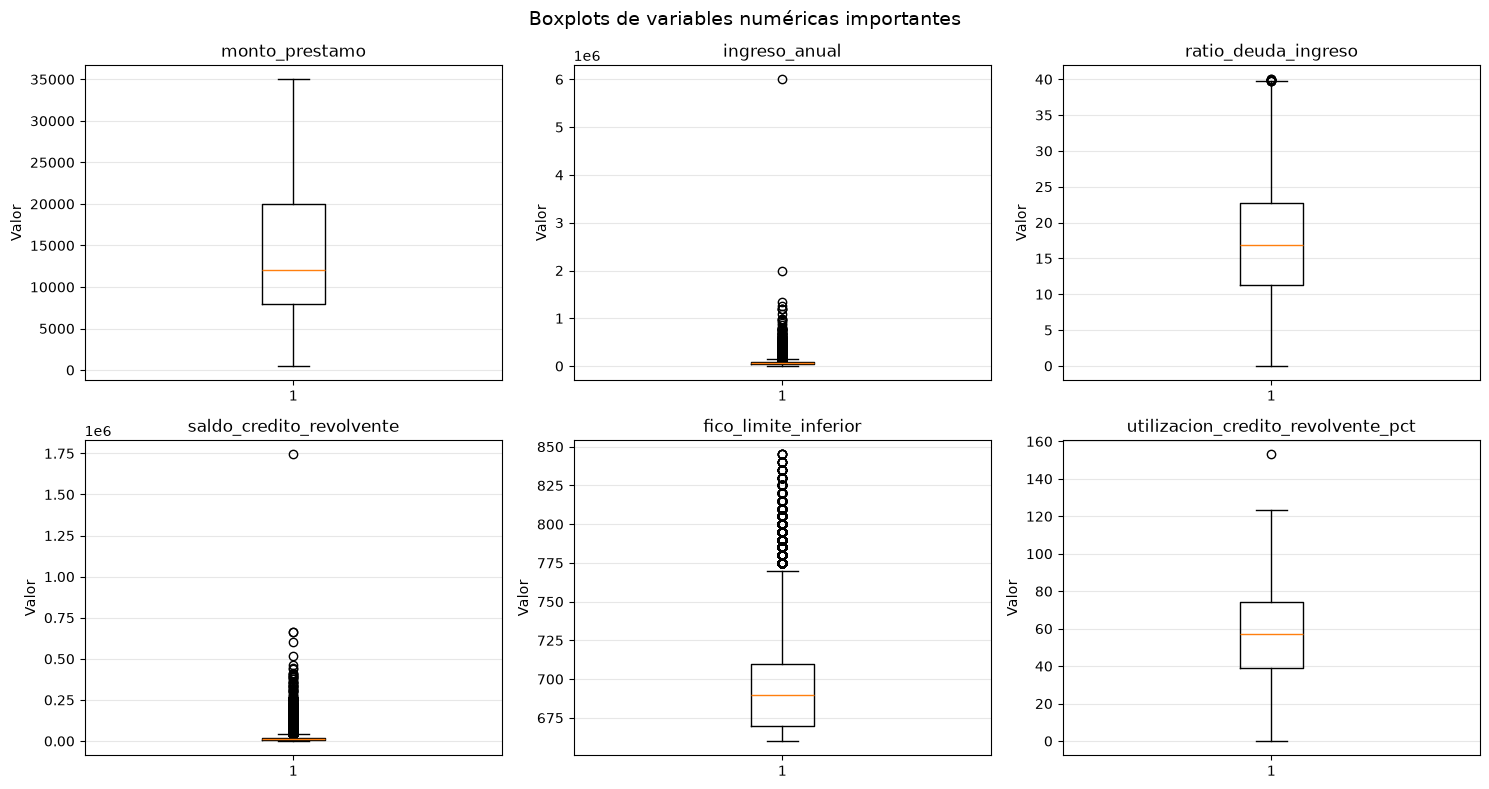

In [22]:
variables_boxplot = [
    "monto_prestamo", "ingreso_anual", "ratio_deuda_ingreso", "saldo_credito_revolvente",
    "fico_limite_inferior", "utilizacion_credito_revolvente_pct"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for eje, variable in zip(axes.ravel(), variables_boxplot):
    eje.boxplot(X_entrenamiento_imputado[variable].dropna(), vert=True)
    eje.set_title(variable)
    eje.set_ylabel("Valor")
    eje.grid(axis="y", alpha=0.3)
fig.suptitle("Boxplots de variables numéricas importantes", fontsize=14)
plt.tight_layout()
display(fig)
plt.close(fig)


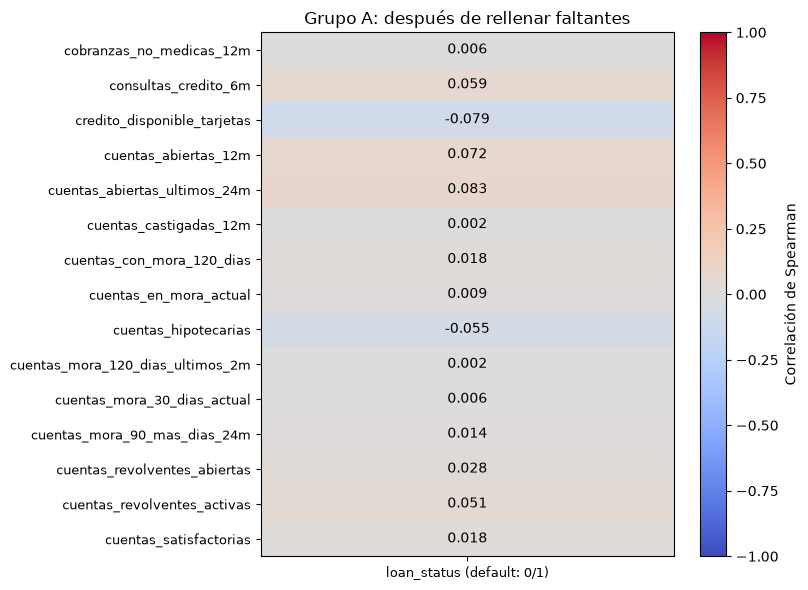

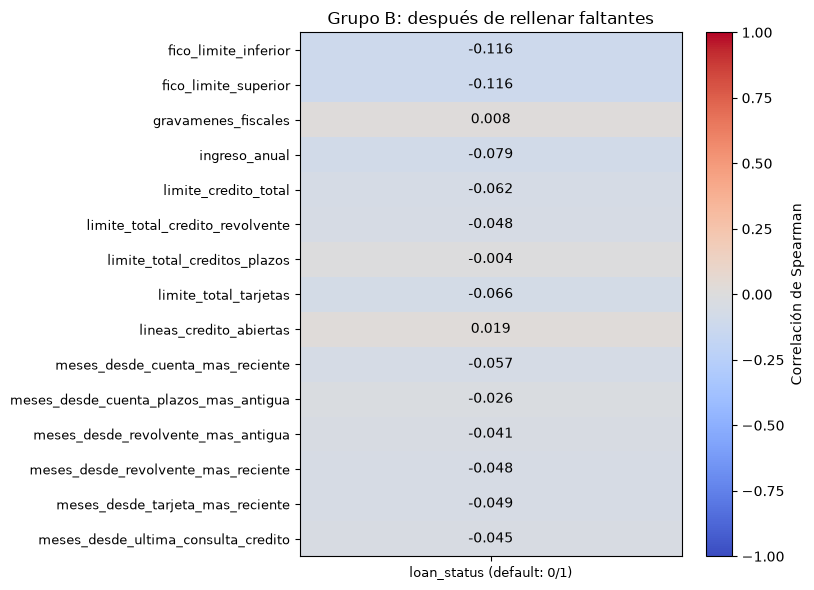

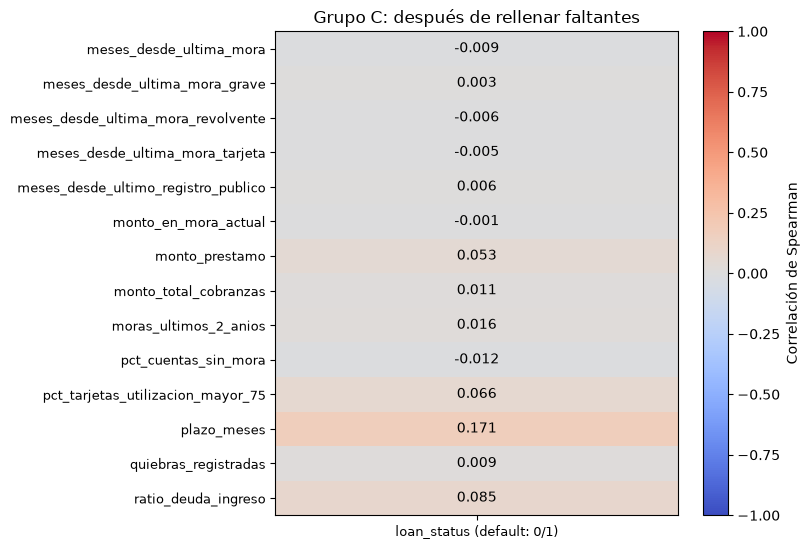

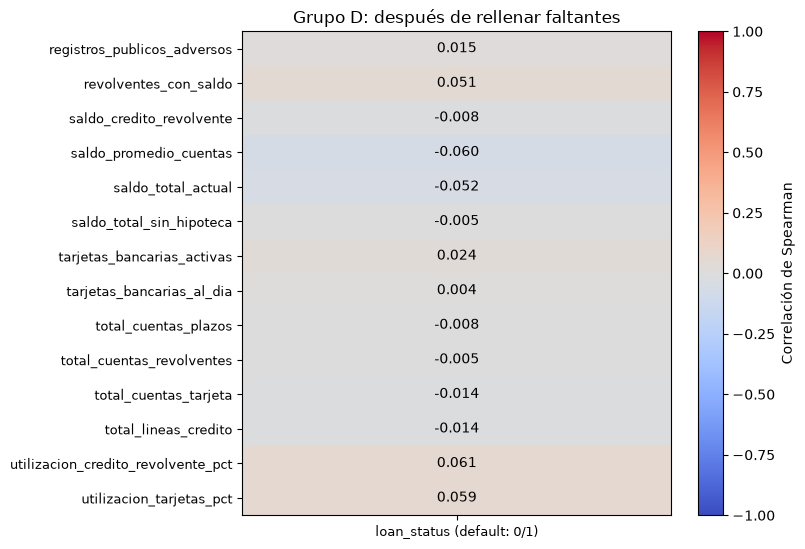

In [23]:
# Mismas predictoras, grupos y escala que en la sección 8.
# No agregamos los indicadores nuevos de faltantes a esta comparación.
correlacion_target_despues = X_entrenamiento_imputado[variables_correlacion].corrwith(
    y_entrenamiento, method="spearman"
).to_frame("correlacion_target")
mostrar_correlacion_objetivo(correlacion_target_despues, "después de rellenar faltantes")


## 15. Preparar las variables para el baseline

Usamos las funciones compartidas de `src/experimentos.py` para que el notebook y el script apliquen las mismas reglas. Las medianas, categorías y escalas se aprenden solo con entrenamiento.

One-Hot Encoding convierte categorías en columnas 0/1 (`drop="first"`, `handle_unknown="ignore"`), sin agrupar categorías poco frecuentes. Los faltantes categóricos se rellenan con `Sin información`.

Creamos `meses_desde_earliest_cr_line`, la diferencia en meses entre el otorgamiento y la primera línea de crédito, y retiramos la fecha original del modelo. Es la antigüedad del historial crediticio.

Se preparan tres escenarios: sin indicadores (baseline), con indicadores, y con indicadores más las ocho variables de Lending Club. Para compartir código con el script, las matrices del modelo usan los nombres originales; el EDA conserva los nombres en español.


In [24]:
from src.experimentos import preparar_experimentos, entrenar_experimentos
from src.evaluate import tabla_metricas

# Recuperar los nombres del archivo para usar las mismas funciones que el script.
# El EDA anterior conserva sus nombres en español.
nombres_originales = {nuevo: original for original, nuevo in nombres_variables.items()}
particiones_modelo = {
    'entrenamiento': df_eda.rename(columns=nombres_originales),
    'validacion': df_validacion.rename(columns=nombres_originales),
    'prueba': df_prueba.rename(columns=nombres_originales),
}
preparados = preparar_experimentos(particiones_modelo, columnas_vacias)

def matrices(escenario):
    datos = preparados[escenario]['X']
    return datos['entrenamiento'], datos['validacion'], datos['prueba']

X_entrenamiento_sin_indicadores, X_validacion_sin_indicadores, X_prueba_sin_indicadores = matrices('logistica_sin_indicadores')
X_entrenamiento_final, X_validacion_final, X_prueba_final = matrices('logistica_con_indicadores')
X_entrenamiento_lc, X_validacion_lc, X_prueba_lc = matrices('logistica_con_precio_lc')
for escenario, datos in preparados.items():
    print(escenario, datos['variables'])
    display(datos['X']['entrenamiento'].head())


C:\Users\josue\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [1, 4, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
C:\Users\josue\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [1, 4, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


C:\Users\josue\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [1, 4, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


C:\Users\josue\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [1, 4, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


C:\Users\josue\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [3, 6, 8, 9] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


logistica_sin_indicadores {'predictoras_evaluadas': 95, 'predictoras_finales': 65, 'columnas_modelo': 138, 'con_indicador_faltante': 0, 'excluidas_por_faltantes': 30}


...

,loan_amnt,term,annual_inc,dti,delinq_2yrs,...,addr_state_VT,addr_state_WA,addr_state_WI,addr_state_WV,addr_state_WY
107387,-0.988508,-0.583111,0.134049,-0.130760,11.081979,...,0.0,0.0,0.0,0.0,0.0
107388,0.831920,1.714940,-0.068656,1.575025,-0.357440,...,0.0,0.0,0.0,0.0,0.0
107390,-0.503061,-0.583111,-0.532243,-1.154742,0.913606,...,0.0,0.0,0.0,0.0,0.0
107391,0.710558,-0.583111,0.095975,1.001748,2.184653,...,0.0,0.0,0.0,0.0,0.0
107392,-0.867147,-0.583111,-0.665501,0.261213,-0.357440,...,0.0,0.0,0.0,0.0,0.0


logistica_con_indicadores {'predictoras_evaluadas': 95, 'predictoras_finales': 65, 'columnas_modelo': 169, 'con_indicador_faltante': 31, 'excluidas_por_faltantes': 30}


,mths_since_last_delinq,mths_since_last_record,mths_since_last_major_derog,tot_coll_amt,tot_cur_bal,...,addr_state_VT,addr_state_WA,addr_state_WI,addr_state_WV,addr_state_WY
107387,-1.372770,0.032057,-3.101763,-0.09725,0.816581,...,0.0,0.0,0.0,0.0,0.0
107388,0.695742,0.032057,2.475926,-0.09725,0.248731,...,0.0,0.0,0.0,0.0,0.0
107390,-1.639675,0.586954,-0.003047,-0.09725,-0.883907,...,0.0,0.0,0.0,0.0,0.0
107391,-1.839853,0.032057,-3.824797,-0.09725,-0.435429,...,0.0,0.0,0.0,0.0,0.0
107392,-0.104972,0.032057,-0.003047,-0.09725,0.416626,...,0.0,0.0,0.0,0.0,0.0


logistica_con_precio_lc {'predictoras_evaluadas': 103, 'predictoras_finales': 73, 'columnas_modelo': 214, 'con_indicador_faltante': 31, 'excluidas_por_faltantes': 30}


,mths_since_last_delinq,mths_since_last_record,mths_since_last_major_derog,tot_coll_amt,tot_cur_bal,...,addr_state_WA,addr_state_WI,addr_state_WV,addr_state_WY,initial_list_status_w
107387,-1.372770,0.032057,-3.101763,-0.09725,0.816581,...,0.0,0.0,0.0,0.0,1.0
107388,0.695742,0.032057,2.475926,-0.09725,0.248731,...,0.0,0.0,0.0,0.0,1.0
107390,-1.639675,0.586954,-0.003047,-0.09725,-0.883907,...,0.0,0.0,0.0,0.0,1.0
107391,-1.839853,0.032057,-3.824797,-0.09725,-0.435429,...,0.0,0.0,0.0,0.0,0.0
107392,-0.104972,0.032057,-0.003047,-0.09725,0.416626,...,0.0,0.0,0.0,0.0,0.0


## 16. Conjuntos finales para entrenar los modelos

A partir de esta sección se pueden entrenar los baselines y los modelos finales.
Usaremos los conjuntos ya preparados, con las mismas columnas y en el mismo orden:

- `X_entrenamiento_final`, `X_validacion_final`, `X_prueba_final`: incluyen los 31 indicadores de faltantes.
- `X_entrenamiento_sin_indicadores`, `X_validacion_sin_indicadores`, `X_prueba_sin_indicadores`: no incluyen esas 31 columnas.
- `y_entrenamiento`, `y_validacion`, `y_prueba`: contienen el objetivo `default`.

El primer modelo puede entrenarse con la versión sin indicadores y el segundo con la versión que los incluye. La comparación se hará con los mismos periodos y métricas. Las variables categóricas ya fueron codificadas, `meses_historial_crediticio` ya fue creada y las variables numéricas ya fueron escaladas usando solo entrenamiento.

El escenario LC añade `X_entrenamiento_lc`, `X_validacion_lc` y `X_prueba_lc`: incluye indicadores y las ocho variables adicionales. Todos usan los mismos objetivos y filas.


In [25]:
X_entrenamiento_modelo = X_entrenamiento_final
X_validacion_modelo = X_validacion_final
X_prueba_modelo = X_prueba_final

X_entrenamiento_modelo_sin_indicadores = X_entrenamiento_sin_indicadores
X_validacion_modelo_sin_indicadores = X_validacion_sin_indicadores
X_prueba_modelo_sin_indicadores = X_prueba_sin_indicadores

resumen_conjuntos_modelo = pd.DataFrame({
    "conjunto": ["Entrenamiento", "Validación", "Prueba"],
    "con_indicadores_filas": [len(X_entrenamiento_modelo), len(X_validacion_modelo), len(X_prueba_modelo)],
    "con_indicadores_columnas": [X_entrenamiento_modelo.shape[1], X_validacion_modelo.shape[1], X_prueba_modelo.shape[1]],
    "sin_indicadores_filas": [len(X_entrenamiento_modelo_sin_indicadores), len(X_validacion_modelo_sin_indicadores), len(X_prueba_modelo_sin_indicadores)],
    "sin_indicadores_columnas": [X_entrenamiento_modelo_sin_indicadores.shape[1], X_validacion_modelo_sin_indicadores.shape[1], X_prueba_modelo_sin_indicadores.shape[1]]
})
display(resumen_conjuntos_modelo)
display(X_entrenamiento_modelo.head())


,conjunto,con_indicadores_filas,con_indicadores_columnas,sin_indicadores_filas,sin_indicadores_columnas
0,Entrenamiento,73701,169,73701,138
1,Validación,109382,169,109382,138
2,Prueba,36920,169,36920,138


,mths_since_last_delinq,mths_since_last_record,mths_since_last_major_derog,tot_coll_amt,tot_cur_bal,...,addr_state_VT,addr_state_WA,addr_state_WI,addr_state_WV,addr_state_WY
107387,-1.372770,0.032057,-3.101763,-0.09725,0.816581,...,0.0,0.0,0.0,0.0,0.0
107388,0.695742,0.032057,2.475926,-0.09725,0.248731,...,0.0,0.0,0.0,0.0,0.0
107390,-1.639675,0.586954,-0.003047,-0.09725,-0.883907,...,0.0,0.0,0.0,0.0,0.0
107391,-1.839853,0.032057,-3.824797,-0.09725,-0.435429,...,0.0,0.0,0.0,0.0,0.0
107392,-0.104972,0.032057,-0.003047,-0.09725,0.416626,...,0.0,0.0,0.0,0.0,0.0


## 17. Baseline: regresion logistica

El enunciado pide un baseline **simple y honesto**: para clasificacion,
regresion logistica. Antes de eso necesitamos un piso contra el cual comparar.

### 17.1. La referencia que hay que superar

`DummyClassifier(strategy="most_frequent")` predice siempre `Fully Paid`.
No mira ninguna variable. Su exactitud sera alta porque el 80% de los prestamos
efectivamente se pagan, y aun asi **no detecta un solo incumplimiento**.

Esa fila es la razon por la que este proyecto no reporta accuracy sola.

In [26]:
resultados_modelos, modelos, scores_validacion = entrenar_experimentos(preparados)
baseline = modelos['logistica_sin_indicadores']
con_indicadores = modelos['logistica_con_indicadores']
con_lc = modelos['logistica_con_precio_lc']
umbral = resultados_modelos['logistica_sin_indicadores']['validacion']['umbral']
umbral_ind = resultados_modelos['logistica_con_indicadores']['validacion']['umbral']
print('Entrenamiento terminado: tres regresiones logísticas y referencia mayoritaria.')


Entrenamiento terminado: tres regresiones logísticas y referencia mayoritaria.


### 17.2. Eleccion del umbral

Un modelo de clasificacion devuelve una probabilidad; convertirla en una
decision requiere un umbral. Elegirlo mirando el conjunto de prueba seria una
forma de leakage, asi que **el umbral se elige en validacion** maximizando F1
y luego se aplica a prueba sin reajustar.

In [27]:
for nombre in modelos:
    print(nombre, 'umbral elegido en validación:', resultados_modelos[nombre]['validacion']['umbral'])


logistica_sin_indicadores umbral elegido en validación: 0.17537662378667151
logistica_con_indicadores umbral elegido en validación: 0.17307958331350895
logistica_con_precio_lc umbral elegido en validación: 0.17815218313265296


### 17.3. Resultados

Cuatro referencias por tres conjuntos. AP (columna PR-AUC) se calcula con Average Precision. La prueba ya fue consultada; las siguientes decisiones se tomarán con validación.


In [28]:
tabla_baseline = tabla_metricas(resultados_modelos)
with pd.option_context('display.max_columns', None):
    display(tabla_baseline)


,modelo,conjunto,n,ROC-AUC,PR-AUC,KS,Recall,Precision,F1,Accuracy
0,logistica_sin_indicadores,entrenamiento,73701,0.7025,0.3234,0.2966,0.6172,0.2773,0.3827,0.6641
1,logistica_sin_indicadores,validacion,109382,0.7121,0.4016,0.3071,0.6344,0.3440,0.4461,0.6637
2,logistica_sin_indicadores,prueba,36920,0.6902,0.3584,0.2825,0.5764,0.3348,0.4235,0.6667
3,logistica_con_indicadores,entrenamiento,73701,0.7031,0.3241,0.2958,0.6271,0.2758,0.3831,0.6594
4,logistica_con_indicadores,validacion,109382,0.7128,0.4025,0.3079,0.6495,0.3403,0.4466,0.6564
5,logistica_con_indicadores,prueba,36920,0.6922,0.3610,0.2864,0.5917,0.3330,0.4262,0.6615
6,logistica_con_precio_lc,entrenamiento,73701,0.7103,0.3315,0.3056,0.6326,0.2802,0.3884,0.6639
7,logistica_con_precio_lc,validacion,109382,0.7243,0.4125,0.3284,0.6543,0.3515,0.4573,0.6685
8,logistica_con_precio_lc,prueba,36920,0.7020,0.3698,0.3023,0.6192,0.3369,0.4364,0.6602
9,clase_mayoritaria,entrenamiento,73701,0.5000,0.1687,0.0000,0.0000,0.0000,0.0000,0.8313


### 17.4. Matriz de confusion en validacion

`Charged Off` es la clase positiva. Los falsos negativos (abajo a la izquierda)
son los prestamos que el modelo aprobaria y terminarian sin pagarse: son los
errores que cuestan dinero.

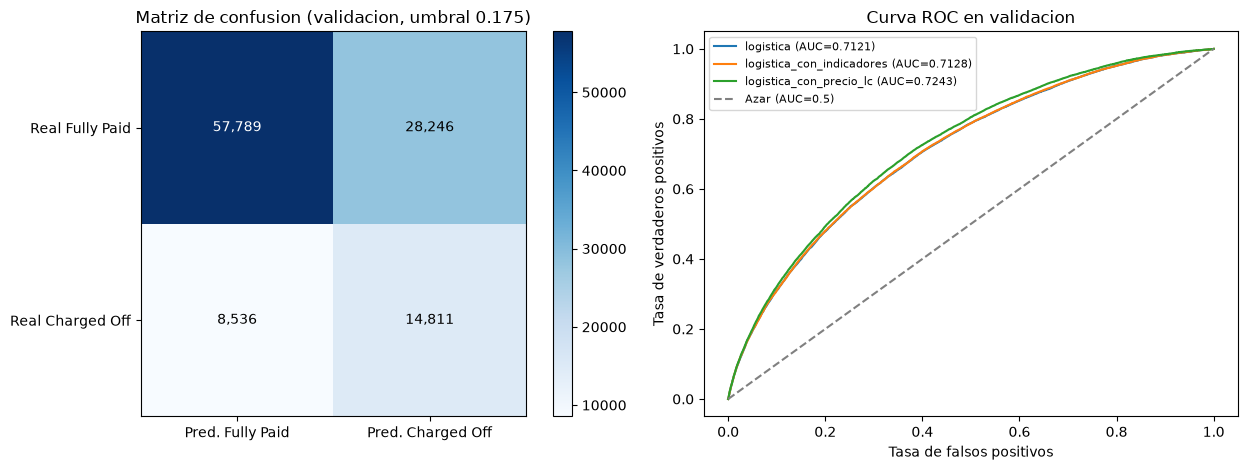

Incumplimientos detectados: 14,811 de 23,347 (63.4%)
Prestamos buenos rechazados por error: 28,246 de 86,035 (32.8%)


In [29]:
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
score_validacion = baseline.predict_proba(X_validacion_sin_indicadores)[:, 1]
prediccion = (score_validacion >= umbral).astype(int)
matriz = confusion_matrix(y_validacion, prediccion, labels=[0, 1])

fig, ejes = plt.subplots(1, 2, figsize=(13, 4.8))

imagen = ejes[0].imshow(matriz, cmap="Blues")
ejes[0].set_xticks([0, 1], labels=["Pred. Fully Paid", "Pred. Charged Off"])
ejes[0].set_yticks([0, 1], labels=["Real Fully Paid", "Real Charged Off"])
for i in range(2):
    for j in range(2):
        ejes[0].text(j, i, f"{matriz[i, j]:,}", ha="center", va="center",
                     color="white" if matriz[i, j] > matriz.max() / 2 else "black")
ejes[0].set_title(f"Matriz de confusion (validacion, umbral {umbral:.3f})")
fig.colorbar(imagen, ax=ejes[0])

for nombre, modelo, X in [("logistica", baseline, X_validacion_sin_indicadores),
                          ("logistica_con_indicadores", con_indicadores,
                           X_validacion_final),
                          ("logistica_con_precio_lc", con_lc, X_validacion_lc)]:
    fpr, tpr, _ = roc_curve(y_validacion, modelo.predict_proba(X)[:, 1])
    ejes[1].plot(fpr, tpr, label=f"{nombre} (AUC={roc_auc_score(y_validacion, modelo.predict_proba(X)[:, 1]):.4f})")
ejes[1].plot([0, 1], [0, 1], "--", color="gray", label="Azar (AUC=0.5)")
ejes[1].set_xlabel("Tasa de falsos positivos")
ejes[1].set_ylabel("Tasa de verdaderos positivos")
ejes[1].set_title("Curva ROC en validacion")
ejes[1].legend(fontsize=8)

plt.tight_layout()
display(fig)
plt.close(fig)

vn, fp, fn, vp = matriz.ravel()
print(f"Incumplimientos detectados: {vp:,} de {vp + fn:,} ({vp / (vp + fn):.1%})")
print(f"Prestamos buenos rechazados por error: {fp:,} de {vn + fp:,} ({fp / (vn + fp):.1%})")

### 17.5. Coeficientes del baseline

Las numéricas se interpretan por desviación estándar y las categorías respecto a su referencia. `exp(coef)` multiplica las odds, `p/(1-p)`, no la probabilidad directamente. Los coeficientes no demuestran causalidad ni ausencia de leakage.


,variable,coeficiente,odds_ratio,magnitud
0,purpose_small_business,0.7564,2.1307,0.7564
1,addr_state_VT,-0.6641,0.5147,0.6641
2,addr_state_WY,-0.6039,0.5467,0.6039
3,emp_length_Sin información,0.5086,1.6629,0.5086
4,addr_state_NH,-0.4723,0.6235,0.4723
5,purpose_wedding,-0.4581,0.6325,0.4581
6,addr_state_DC,-0.4278,0.6520,0.4278
7,purpose_medical,0.4031,1.4965,0.4031
8,addr_state_HI,-0.3889,0.6778,0.3889
9,term,0.3881,1.4742,0.3881


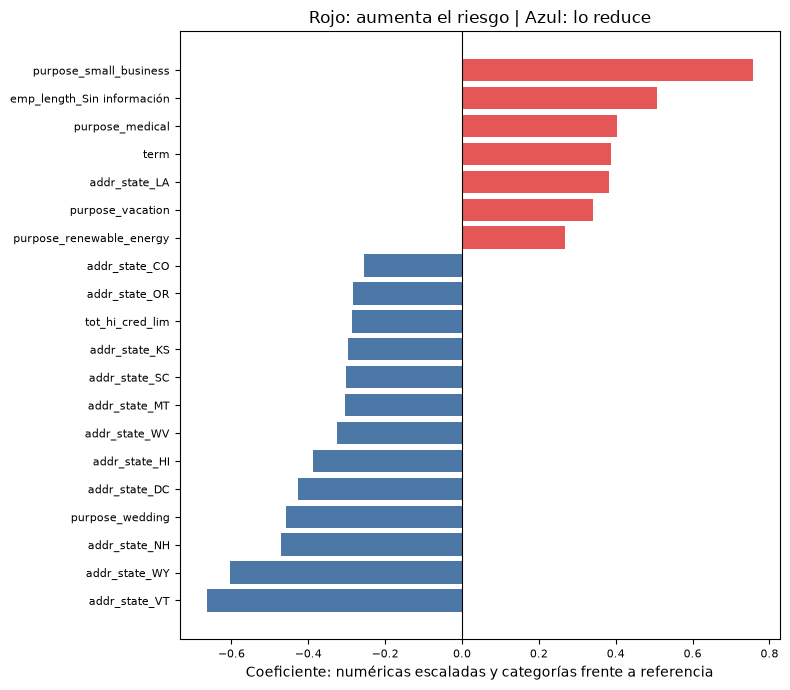

In [30]:
coeficientes = pd.DataFrame({
    "variable": X_entrenamiento_sin_indicadores.columns,
    "coeficiente": baseline.coef_[0],
})
coeficientes["odds_ratio"] = np.exp(coeficientes["coeficiente"])
coeficientes["magnitud"] = coeficientes["coeficiente"].abs()
top = coeficientes.sort_values("magnitud", ascending=False).head(20)
display(top.round(4).reset_index(drop=True))

fig, eje = plt.subplots(figsize=(8, 7))
orden = top.sort_values("coeficiente")
eje.barh(orden["variable"],
         orden["coeficiente"],
         color=["#E45756" if c > 0 else "#4C78A8" for c in orden["coeficiente"]])
eje.axvline(0, color="black", linewidth=0.8)
eje.set_xlabel("Coeficiente: numéricas escaladas y categorías frente a referencia")
eje.set_title("Rojo: aumenta el riesgo | Azul: lo reduce")
eje.tick_params(labelsize=8)
plt.tight_layout()
display(fig)
plt.close(fig)

## 18. Lectura del resultado

Comparamos la regresión logística sin indicadores con la referencia que siempre predice Fully Paid. Después evaluamos el aporte de los indicadores y, manteniéndolos, el de las ocho variables adicionales de Lending Club.

ROC-AUC y Average Precision evalúan los scores; precisión, recall y F1 dependen del umbral elegido en validación. Que la validación supere al entrenamiento no demuestra ausencia de sobreajuste. Los cambios entre años y el seguimiento incompleto podrían influir en prueba; debemos verificarlo antes de concluir causas.

## 19. Pipeline reproducible

`python -m src.run_baseline` utiliza las mismas funciones de preparación, entrenamiento y evaluación de las secciones 15–17. Los resultados deben coincidir al usar el mismo archivo, muestra y versiones. Los cambios en estas reglas requieren regenerar métricas y documentación.


## 20. Referencias

scikit-learn developers. (s. f.). *Imputation of missing values*. scikit-learn.
Recuperado el 21 de septiembre de 2026, de
[https://scikit-learn.org/stable/modules/impute.html](https://scikit-learn.org/stable/modules/impute.html)
